# Robust MIP Peak Extraction for FV0 Ring 5 (per-channel)

This notebook proposes and demonstrates a **robust** method to estimate the MIP peak (MPV) from amplitude spectra **even when the true MIP peak bin is _not_ the global maximum bin** (e.g., due to electronics bit-shifts, software triggers, or other artifacts).

We compare two approaches:
1. **Current (baseline) method** — anchor on the **maximum-count bin**, pick a fractional window around it, fit a **Gaussian**, and take its mean as the MIP value.
2. **Robust method (SMIRK)** — **S**moothing (Gaussian/KDE-like), **M**ode isolation with prominence inside robust quantile bounds, **I**nfer an **R**ealistic window around the smoothed mode, and **K**-order (parabolic) refinement of the peak; then (optionally) fit a local **Gaussian** (or **exponentially modified Gaussian** a.k.a. *exGaussian*) **anchored at the refined mode**. The reported MIP is the refined-mode position (or the anchored-fit MPV).

Key ideas of the robust method:
- Avoid relying on a possibly wrong global max bin.
- Smooth the histogram (variance-stabilized) to suppress single-bin glitches.
- Search for the most **prominent** local maximum in a **robust quantile window** (e.g., between 10th and 90th percentiles of the cumulative counts).
- **Refine** the maximum using a **parabolic interpolation** near the top (sub-bin resolution).
- Define an **adaptive fit window** from where the smoothed curve falls to a fixed fraction of the peak; fit a local Gaussian (or exGaussian) with **Poisson-aware weights**.
- Return the refined-mode (or fitted MPV) as the MIP estimate.

We also generate **synthetic distortions** by **demoting the true max bin** to 80% of the new max so that it is **no longer** the maximum, to test robustness.


In [21]:
# Cell 0: Imports & configuration
import json
from datetime import datetime
import numpy as np
import pandas as pd
import polars as pl
from pathlib import Path
import uproot
from scipy.optimize import curve_fit, least_squares
from scipy import stats, signal, ndimage
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
import warnings
warnings.filterwarnings('ignore')

# --- Configuration (modify as needed) ---
IN_DIR = "/home/mvishiu11/Desktop/CERN/LHC-aging-analysis/data/physicsROOT/"
PHYSICS_RUN_JSON = "/home/mvishiu11/Desktop/CERN/LHC-aging-analysis/data/physicsROOT/physics_runs.json"

# Histogram binning
HIST_BINS = 4100
HIST_RANGE = (0, 4100)

print("Configuration loaded successfully!")
print(f"Data directory: {IN_DIR}")

Configuration loaded successfully!
Data directory: /home/mvishiu11/Desktop/CERN/LHC-aging-analysis/data/physicsROOT/


In [23]:
# Cell 1: Run metadata utilities & ROOT helpers
def load_run_timestamps(json_file):
    """Load run timestamps, beam types, and polarity from physics_runs.json file"""
    with open(json_file, 'r') as f:
        run_data = json.load(f)
    run_info = {}
    beam_configs = {}
    for entry in run_data:
        run_num = entry['run']
        run_info[run_num] = {
            'timestamp': entry['start_ms'],
            'polarity': entry['polarity'],
            'beam_type': entry['beamType']
        }
        config_key = f"{entry['beamType']} ({entry['polarity']})"
        beam_configs.setdefault(config_key, []).append(run_num)
    print(f"Loaded information for {len(run_info)} runs")
    print("Beam configurations found:")
    for config, runs in beam_configs.items():
        print(f"  {config}: {len(runs)} runs")
    return run_info, beam_configs

def extract_run_number(filename):
    """Extract run number from filename like 'run_564250_ft0digits.root'"""
    match = re.search(r'run_(\d{6})_ft0digits\.root', filename)
    return int(match.group(1)) if match else None

def get_root_files(directory):
    """Get all .root files matching the pattern in directory"""
    files = []
    for file in Path(directory).glob("run_*_ft0digits.root"):
        run_num = extract_run_number(file.name)
        if run_num:
            files.append((str(file), run_num))
    files.sort(key=lambda x: x[1])
    print(f"Found {len(files)} ROOT files")
    return files

def create_histogram_for_channel(tree, ch_id:int):
    """Create histogram for a specific channel ID."""
    try:
        qtc_ampl = tree["FV0DIGITSCH/FV0DIGITSCH.QTCAmpl"].array(library="np")
        channel_id = tree["FV0DIGITSCH/FV0DIGITSCH.ChId"].array(library="np")
        qtc_flat = np.concatenate(qtc_ampl)
        ch_flat  = np.concatenate(channel_id)
        mask = (ch_flat == ch_id)
        filtered_qtc = qtc_flat[mask]
        hist, bin_edges = np.histogram(filtered_qtc, bins=HIST_BINS, range=HIST_RANGE)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        return hist.astype(float), bin_centers
    except Exception as e:
        print(f"  Error creating histogram for channel {ch_id}: {e}")
        return None, None

# Load metadata (optional at this stage)
try:
    run_info, beam_configurations = load_run_timestamps(PHYSICS_RUN_JSON)
    print("\nSample run information:")
    for i, (run, info) in enumerate(list(run_info.items())[:3]):
        dt = datetime.fromtimestamp(info['timestamp']/1000)
        print(f"  Run {run}: {dt} | {info['beam_type']} | {info['polarity']}")
except Exception as e:
    print("Could not load run metadata:", e)

Loaded information for 25 runs
Beam configurations found:
  NE10 - NE10 (POSITIVE): 3 runs
  O8 - O8 (POSITIVE): 13 runs
  PROTON - O8 (POSITIVE): 9 runs

Sample run information:
  Run 564472: 2025-07-09 00:08:15.222000 | NE10 - NE10 | POSITIVE
  Run 564470: 2025-07-08 23:44:30.690000 | NE10 - NE10 | POSITIVE
  Run 564468: 2025-07-08 16:30:15.282000 | NE10 - NE10 | POSITIVE


## Methods

### Baseline (current) method
1. Find the **global max bin** at position \(x_{\max}\).
2. Define a fractional window \([a\,x_{\max},\,b\,x_{\max}]\) (often \(a=1-z\), \(b=1+z\)).
3. Fit a **Gaussian** on that window (least squares), report the **mean** as MIP.

### Robust method (SMIRK)
1. **Smooth** the histogram with a modest Gaussian (KDE-like) to suppress single-bin artifacts (Poisson variance aware).
2. Compute the cumulative counts and limit the **search region** to robust quantiles (e.g. 10%–90%).
3. Use **prominence-based peak finding** on the smoothed curve to get the candidate MIP **mode**.
4. **Parabolic refinement** around the smoothed maximum to achieve sub-bin resolution.
5. Build an **adaptive window** using where the smoothed curve falls below a fixed fraction of the peak (e.g. 60%) on left/right.
6. Optionally fit a **Gaussian** (or **exGaussian**) **anchored** at the refined mode and within this adaptive window; report the refined mode (or fitted MPV) as MIP.


In [3]:
# Cell 2: Implementations

def gaussian(x, A, mu, sigma, C):
    return A * np.exp(-0.5 * ((x - mu)/sigma)**2) + C

def exgaussian_pdf(x, K, loc, scale):
    """Exponentially modified Gaussian (exGaussian) PDF via scipy.stats.exponnorm.
    K>0 is the shape (K = tau/sigma). loc~mu, scale~sigma.
    """
    return stats.exponnorm.pdf(x, K, loc=loc, scale=scale)

def old_method_gaussian(hist, x, z=0.2):
    """Baseline: anchor on global max bin, fit Gaussian in fractional window [x*(1-z), x*(1+z)].
    Returns (mip_estimate, popt, pcov). Falls back to max-bin center if fit fails.
    """
    if hist is None or np.nansum(hist) <= 0:
        return np.nan, None, None
    
    i_max = int(np.nanargmax(hist))
    x_max = x[i_max]
    a, b = (1-z), (1+z)
    left, right = a * x_max, b * x_max
    mask = (x >= left) & (x <= right) & (hist > 0)
    if mask.sum() < 5:
        return x_max, None, None
    
    # Weights ~ 1/sigma_y with Poisson sigma ~ sqrt(N)
    y = hist[mask].astype(float)
    xc = x[mask]
    w = 1.0 / np.maximum(np.sqrt(y), 1.0)
    
    # Initial guess
    A0   = y.max() - np.median(y[:3])
    mu0  = xc[np.argmax(y)]
    sig0 = max((right-left)/6, 1.0)
    C0   = np.median(y[:3])
    p0 = [A0, mu0, sig0, C0]
    
    try:
        popt, pcov = curve_fit(gaussian, xc, y, p0, sigma=w, absolute_sigma=False, maxfev=5000)
        mip = popt[1]
        return mip, popt, pcov
    except Exception:
        return x_max, None, None

def smooth_counts(hist, sigma_bins=None):
    """Gaussian smoothing of counts; sigma in bins. If None, pick adaptively."""
    if sigma_bins is None:
        # Adaptive: small fraction of total bins, bounded [1, 8]
        sigma_bins = max(1.0, min(8.0, 0.01 * len(hist)))
    return gaussian_filter1d(hist.astype(float), sigma=sigma_bins)

def robust_mode_from_smoothed(hist, x, qlow=0.10, qhigh=0.90, prominence=None, sigma_bins=None):
    """Find the most prominent local maximum of the smoothed histogram in [qlow, qhigh] quantile bounds."""
    y = hist.astype(float)
    if y.sum() <= 0:
        return None, None, None, None
    y_s = smooth_counts(y, sigma_bins=sigma_bins)
    
    # Quantile bounds on *data* via cumulative counts
    cdf = np.cumsum(y) / y.sum()
    left_idx  = np.searchsorted(cdf, qlow)
    right_idx = np.searchsorted(cdf, qhigh)
    left_idx  = max(0, min(left_idx, len(x)-1))
    right_idx = max(left_idx+3, min(right_idx, len(x)-1))
    
    # Peak finding
    if prominence is None:
        # Poisson-inspired: a few sqrt(max) counts
        prominence = max(3.0*np.sqrt(y_s.max()), 0.01*y_s.max())
    peaks, props = signal.find_peaks(y_s[left_idx:right_idx], prominence=prominence)
    if len(peaks) == 0:
        # Fall back: take absolute max within bounds
        i_local = int(np.argmax(y_s[left_idx:right_idx]))
        peak_idx = left_idx + i_local
        return x[peak_idx], peak_idx, y_s, (left_idx, right_idx)
    # Choose the most prominent peak
    best = int(np.argmax(props['prominences']))
    peak_idx = left_idx + int(peaks[best])
    return x[peak_idx], peak_idx, y_s, (left_idx, right_idx)

def parabolic_refine(x, y_s, i0, span=2):
    """Sub-bin peak refinement using a quadratic fit around i0 on smoothed data.
    span = number of bins to either side (at least 1)."""
    i1 = max(0, i0 - span); i2 = min(len(x)-1, i0 + span)
    xs = x[i1:i2+1]; ys = y_s[i1:i2+1]
    if len(xs) < 3:
        return x[i0]
    # Fit y = ax^2 + bx + c
    X = np.vstack([xs**2, xs, np.ones_like(xs)]).T
    try:
        a,b,c = np.linalg.lstsq(X, ys, rcond=None)[0]
        if a >= 0:
            return x[i0]
        xv = -b/(2*a)
        # If outside [xs.min, xs.max], clamp
        if xv < xs.min() or xv > xs.max():
            return x[i0]
        return xv
    except Exception:
        return x[i0]

def adaptive_window_from_smoothed(x, y_s, peak_idx, frac=0.60):
    """Find window where smoothed counts >= frac * peak around peak_idx."""
    y0 = y_s[peak_idx] * frac
    L = peak_idx
    while L > 0 and y_s[L] >= y0:
        L -= 1
    R = peak_idx
    while R < len(y_s)-1 and y_s[R] >= y0:
        R += 1
    # Ensure minimum width of 7 bins
    minw = 7
    if R-L+1 < minw:
        pad = (minw - (R-L+1))//2 + 1
        L = max(0, peak_idx - pad)
        R = min(len(x)-1, peak_idx + pad)
    return L, R

def robust_method(hist, x, qlow=0.10, qhigh=0.90, sigma_bins=None, frac=0.60,
                  fit_model='gauss'):
    """Robust MIP estimator.
    Steps: smooth -> prominent peak in quantile window -> parabolic refinement -> adaptive window -> optional anchored fit
    Returns dict with keys:
      'mip_mode', 'mip_fit', 'window_idx', 'x_smooth', 'y_smooth', 'fit_params'
    """
    if hist is None or np.nansum(hist) <= 0:
        return {'mip_mode': np.nan, 'mip_fit': np.nan}
    
    mode_x, peak_idx, y_s, (Lq, Rq) = robust_mode_from_smoothed(hist, x, qlow, qhigh, sigma_bins=sigma_bins)
    if peak_idx is None:
        return {'mip_mode': np.nan, 'mip_fit': np.nan}
    mode_refined = parabolic_refine(x, y_s, peak_idx, span=2)
    L, R = adaptive_window_from_smoothed(x, y_s, peak_idx, frac=frac)
    mask = np.zeros_like(x, dtype=bool)
    mask[L:R+1] = True
    
    # Optional anchored fit inside [L,R]
    mip_fit = mode_refined
    fit_params = None
    
    if fit_model == 'gauss':
        y = hist[mask].astype(float)
        xc = x[mask]
        if len(xc) >= 5 and y.max() > 0:
            w = 1.0 / np.maximum(np.sqrt(y), 1.0)
            A0   = y.max() - np.median(y[:3])
            mu0  = mode_refined
            sig0 = max((xc.max()-xc.min())/6, 1.0)
            C0   = np.median(y[:3])
            p0 = [A0, mu0, sig0, C0]
            try:
                popt, pcov = curve_fit(gaussian, xc, y, p0, sigma=w, absolute_sigma=False, maxfev=5000)
                mip_fit = popt[1]
                fit_params = ('gauss', popt)
            except Exception:
                pass
    elif fit_model == 'exgauss':
        # Fit exGaussian to *shape* (scaled) in [L,R]
        y = hist[mask].astype(float)
        xc = x[mask]
        if len(xc) >= 6 and y.max() > 0:
            # Normalize y to form pseudo-PDF shape
            ys = y / np.trapz(y, xc)
            def model(theta):
                K, loc, scale = theta
                return stats.exponnorm.pdf(xc, K, loc=loc, scale=scale)
            def resid(theta):
                K, loc, scale = theta
                if scale <= 0 or K <= 0:
                    return 1e3*np.ones_like(ys)
                return (model(theta) - ys) * np.sqrt(np.maximum(y,1.0))  # Poisson-ish weights
            # initial guess
            K0 = 1.5
            loc0 = mode_refined
            scale0 = max((xc.max()-xc.min())/8, 1.0)
            theta0 = np.array([K0, loc0, scale0])
            try:
                res = least_squares(resid, theta0, bounds=([0.1, xc.min(), 1e-3], [10.0, xc.max(), (xc.max()-xc.min())]))
                Kf, locf, scalef = res.x
                # MPV of exGaussian (mode) can be found by maximizing the pdf on a fine grid:
                grid = np.linspace(xc.min(), xc.max(), 2000)
                ypdf = stats.exponnorm.pdf(grid, Kf, loc=locf, scale=scalef)
                mip_fit = grid[np.argmax(ypdf)]
                fit_params = ('exgauss', (Kf, locf, scalef))
            except Exception:
                pass
    
    return {
        'mip_mode': mode_refined,
        'mip_fit': mip_fit,
        'window_idx': (L, R),
        'x_smooth': x,
        'y_smooth': y_s,
        'fit_params': fit_params
    }

## Synthetic distortions

To emulate electronics issues where the true MIP bin is not the global maximum, we **demote** the original max bin so it's only **80% of the new maximum** (ensuring it is no longer the max). We also provide optional utilities to simulate simple bit-shifts or spillover between neighboring bins.


In [4]:
# Cell 3: Synthetic distortion utilities

def demote_max_bin(hist, target_ratio=0.80, ensure_not_max=True):
    """Lower the current maximum bin so that it becomes target_ratio * NEW maximum.
    If ensure_not_max=True, guarantee it is no longer the maximum bin afterward.
    Returns a copy of the histogram.
    """
    h = hist.astype(float).copy()
    if len(h) == 0 or np.all(h == 0):
        return h
    i_max = int(np.argmax(h))
    # Determine the second-highest after removing current max
    tmp = h.copy()
    tmp[i_max] = -np.inf
    i_second = int(np.argmax(tmp))
    second_val = h[i_second]
    # We want new h[i_max] < h[i_second], e.g., h[i_max] = target_ratio * h[i_second]
    new_val = target_ratio * second_val
    h[i_max] = min(h[i_max], new_val)
    if ensure_not_max and h[i_max] >= second_val:
        # Force a small epsilon below
        h[i_max] = 0.99 * second_val
    return h

def spillover_shift(hist, fraction=0.2, direction=+1):
    """Move a fraction of each bin to its neighbor (simulating bit-shift/leakage).
    direction=+1 shifts to the right, -1 to the left.
    """
    h = hist.astype(float).copy()
    out = h.copy()
    if direction > 0:
        out[1:] += fraction * h[:-1]
        out[:-1] -= fraction * h[:-1]
    else:
        out[:-1] += fraction * h[1:]
        out[1:]  -= fraction * h[1:]
    out = np.clip(out, 0.0, None)
    return out

def make_landau_like_sample(n=20000, mpv=1500, xi=150, noise_sigma=4.0, rng=None):
    """Generate a synthetic Landau-like sample using an exGaussian approximation and additive Gaussian noise."""
    rng = np.random.default_rng(rng)
    # exGaussian parameters
    K = 1.5          # shape
    scale = xi/3.0   # approx relation just for shape
    loc = mpv - scale*K  # put the mode near mpv
    x = stats.exponnorm.rvs(K, loc=loc, scale=scale, size=n, random_state=rng)
    x = x + rng.normal(0, noise_sigma, size=n)
    x = np.clip(x, HIST_RANGE[0], HIST_RANGE[1])
    hist, edges = np.histogram(x, bins=HIST_BINS, range=HIST_RANGE)
    centers = 0.5*(edges[:-1] + edges[1:])
    return hist.astype(float), centers

## Visualization helpers

In [42]:
# Cell 4: Plotting helpers

def plot_compare(hist, x, title, z=0.2, robust_kwargs=None, fit_model='gauss',
                 xlim=None, ylim=None, auto_zoom=False, auto_margin=0.15):
    robust_kwargs = robust_kwargs or {}
    mip_old, popt_old, _ = old_method_gaussian(hist, x, z=z)
    res = robust_method(hist, x, fit_model=fit_model, **robust_kwargs)
    mip_mode = res['mip_mode']
    mip_fit  = res['mip_fit']
    L, R = res['window_idx'] if res.get('window_idx') else (None, None)

    fig, ax = plt.subplots(1, 1, figsize=(9, 4))
    ax.step(x, hist, where='mid', label='Histogram', alpha=0.6)
    if res.get('y_smooth') is not None:
        ax.plot(res['x_smooth'], res['y_smooth'], label='Smoothed', linewidth=1.5)
    if L is not None and R is not None:
        ax.axvspan(x[L], x[R], color='gray', alpha=0.15, label='Adaptive window')

    ax.axvline(mip_old, linestyle='--', label=f'Old method: {mip_old:.2f}')
    ax.axvline(mip_mode, linestyle='-.', label=f'Robust mode: {mip_mode:.2f}')
    ax.axvline(mip_fit,  linestyle=':',  label=f'Robust fit: {mip_fit:.2f}')
    ax.set_xlabel('Q (ch)'); ax.set_ylabel('Counts'); ax.set_title(title)

    # --- zoom logic ---
    if auto_zoom and (L is not None and R is not None):
        xw = x[R] - x[L]
        xl = x[L] - auto_margin*xw
        xr = x[R] + auto_margin*xw
        ax.set_xlim(max(x.min(), xl), min(x.max(), xr))
        # y-limit around the local window for visibility
        y_local = hist[L:R+1]
        ymax = max(1.0, y_local.max())
        ax.set_ylim(0, 1.2*ymax)

    if xlim is not None: ax.set_xlim(*xlim)
    if ylim is not None: ax.set_ylim(*ylim)

    ax.legend()
    plt.show()

    return {'old': mip_old, 'robust_mode': mip_mode, 'robust_fit': mip_fit}

## Quick demo on synthetic data

We first show the behavior on a synthetic Landau-like histogram. Then we **demote** the max bin to ensure the true peak is **not** the global maximum and compare the estimates.


Original synthetic:


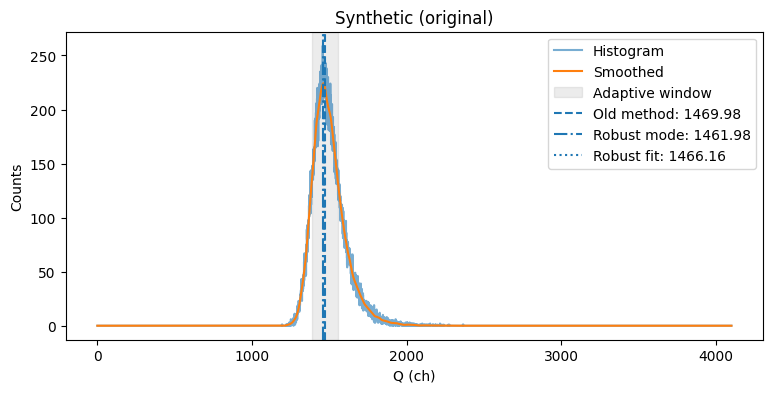

{'old': np.float64(1469.981809335322), 'robust_mode': np.float64(1461.9801364607715), 'robust_fit': np.float64(1466.159029480296)}

Demoted-peak synthetic (true MIP bin not global max):


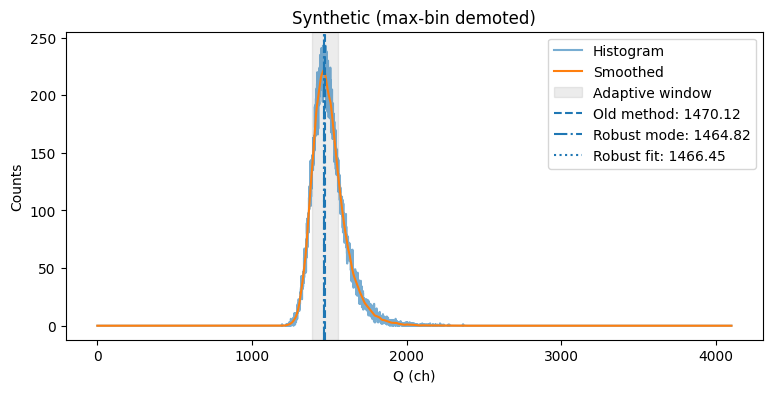

{'old': np.float64(1470.1247138244594), 'robust_mode': np.float64(1464.8209625336017), 'robust_fit': np.float64(1466.4523690284025)}


In [27]:
# Cell 5: Synthetic demo
hist_syn, x_syn = make_landau_like_sample(n=50000, mpv=1500, xi=180, noise_sigma=3.0, rng=42)
print('Original synthetic:')
out1 = plot_compare(hist_syn, x_syn, 'Synthetic (original)', z=0.20, robust_kwargs={'qlow':0.10,'qhigh':0.90,'frac':0.60}, fit_model='gauss')
print(out1)

hist_demoted = demote_max_bin(hist_syn, target_ratio=0.80, ensure_not_max=True)
print('\nDemoted-peak synthetic (true MIP bin not global max):')
out2 = plot_compare(hist_demoted, x_syn, 'Synthetic (max-bin demoted)', z=0.20, robust_kwargs={'qlow':0.10,'qhigh':0.90,'frac':0.60}, fit_model='gauss')
print(out2)

## Per-channel demo from a ROOT file (FV0)

Below we:
1. Open the first ROOT file found in `IN_DIR`.
2. Pick a channel ID (you can iterate or select multiple).
3. Build its histogram.
4. Optionally **distort** it by demoting the max bin.
5. Compare old vs robust methods visually.

> **Note**: Adjust `CHANNEL_ID` to a valid channel. You can also loop over many channels.


In [22]:
# Cell 6: Per-channel ROOT demo
files = get_root_files(IN_DIR)
if len(files) == 0:
    print('No ROOT files found. You can still use the synthetic demo above.')
else:
    root_path, run_num = files[0]
    print('Using file:', root_path, '| run', run_num)
    with uproot.open(root_path) as f:
        # Try to find the digits tree as in your example
        try_names = ["o2sim", "fv0digits", "FV0DIGITSCH"]
        # We will directly access the branches in create_histogram_for_channel()
        tree = f
        # Pick a channel ID to inspect
        CHANNEL_ID = 155  # <-- change as needed
        hist_ch, x_ch = create_histogram_for_channel(tree, CHANNEL_ID)
        if hist_ch is None:
            print('Failed to build histogram for channel', CHANNEL_ID)
        else:
            print(f'Channel {CHANNEL_ID} entries:', int(hist_ch.sum()))
            _ = plot_compare(hist_ch, x_ch, f'Channel {CHANNEL_ID} (original)', z=0.20,
                             robust_kwargs={'qlow':0.10,'qhigh':0.90,'frac':0.60}, fit_model='gauss')
            
            # Distort: demote the max bin so it's no longer the maximum
            hist_ch_dem = demote_max_bin(hist_ch, target_ratio=0.80, ensure_not_max=True)
            _ = plot_compare(hist_ch_dem, x_ch, f'Channel {CHANNEL_ID} (demoted max bin)', z=0.20,
                             robust_kwargs={'qlow':0.10,'qhigh':0.90,'frac':0.60}, fit_model='gauss')

Found 0 ROOT files
No ROOT files found. You can still use the synthetic demo above.


## Batch comparison across many channels

This cell scans a set of channels and prints (or plots) the MIP estimates from both methods. You can add logic to automatically pick channels with sufficient statistics.


In [37]:
import uproot, awkward as ak
from pathlib import Path

# Point to your single MC ROOT file (already in IN_DIR)
root_path = next(Path(IN_DIR).glob("*.root"))
print("Using ROOT file:", root_path)

f = uproot.open(root_path)
print("Top-level keys:", f.keys())  # should include 'o2sim;1'

tree = f["o2sim/FV0DigitCh"]  # MC tree
print("Branch names:")
for k in tree.keys():
    print(" ", k)

Using ROOT file: /home/mvishiu11/Desktop/CERN/LHC-aging-analysis/data/physicsROOT/fv0digits.root
Top-level keys: ['o2sim;1']
Branch names:
  FV0DigitCh.ChId
  FV0DigitCh.ChainQTC
  FV0DigitCh.CFDTime
  FV0DigitCh.QTCAmpl


In [40]:
import numpy as np

# Branch name resolver (picks first that exists)
def first_existing(tree, candidates):
    keys = set(tree.keys())
    for c in candidates:
        if c in keys:
            return c
    raise KeyError(f"None of the candidates exist: {candidates}")

# Resolve branch names for channel ID and amplitude
CH_BRANCH  = first_existing(tree, ["FV0DigitCh.ChId"])
AMP_BRANCH = first_existing(tree, ["FV0DigitCh.QTCAmpl"])  # if your amplitude is different, list candidates here

print("Using branches:", CH_BRANCH, AMP_BRANCH)

def hist_for_channel(tree, ch_id_1indexed, bins=HIST_BINS, rng=HIST_RANGE):
    """
    Build histogram for a single (1-indexed) channel ID from 'o2sim' tree.
    Returns (hist, bin_centers).
    """
    ch_ak  = tree[CH_BRANCH].array(library="ak")   # jagged per event
    amp_ak = tree[AMP_BRANCH].array(library="ak")  # jagged per event

    # Flatten both
    ch  = ak.to_numpy(ak.flatten(ch_ak))
    amp = ak.to_numpy(ak.flatten(amp_ak))

    # Filter for the requested (1-indexed) channel
    mask = (ch == ch_id_1indexed)
    vals = amp[mask]
    hist, edges = np.histogram(vals, bins=bins, range=rng)
    centers = 0.5*(edges[:-1] + edges[1:])
    return hist.astype(float), centers

# Ring 5 channels (1-indexed)
RING5_CHANNELS = list(range(31, 48))  # inclusive 32..48
print("Ring 5 channels (1-indexed):", RING5_CHANNELS)

Using branches: FV0DigitCh.ChId FV0DigitCh.QTCAmpl
Ring 5 channels (1-indexed): [31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]


Ch 31: entries=1995


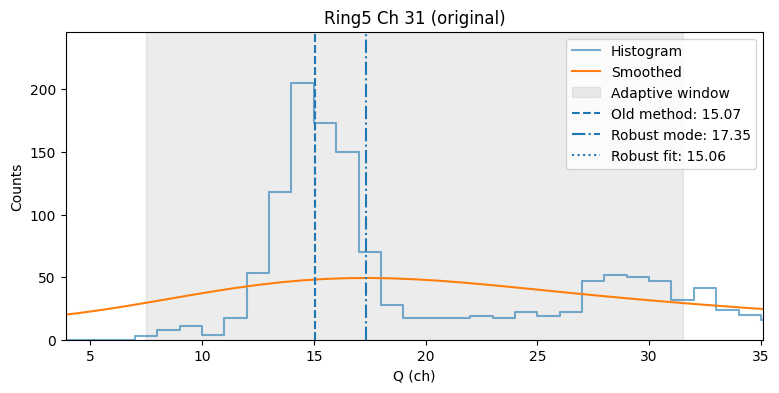

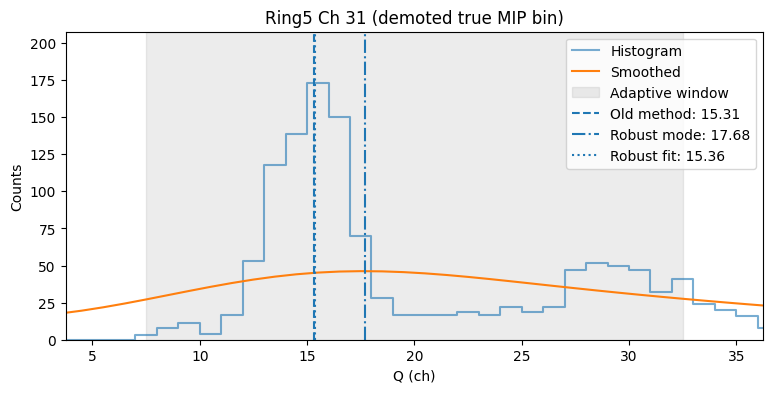

Ch 32: entries=1703


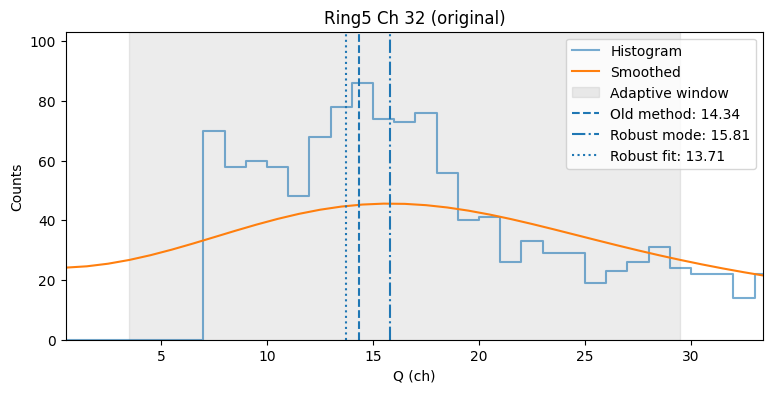

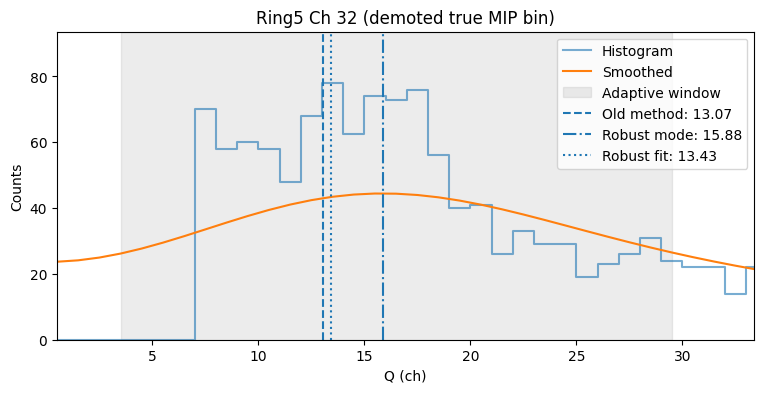

Ch 33: entries=1595


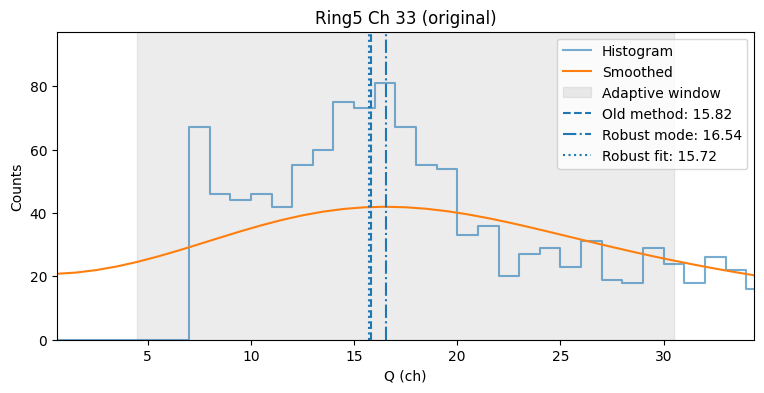

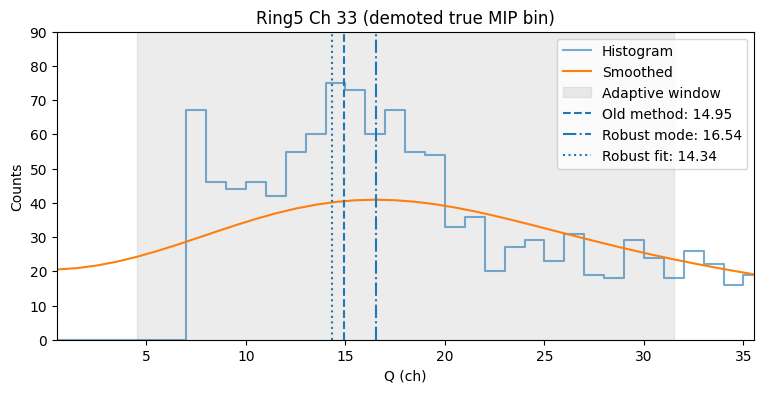

Ch 34: entries=1641


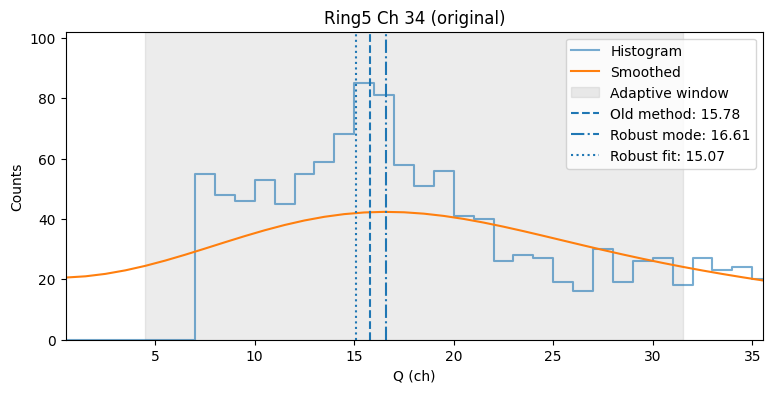

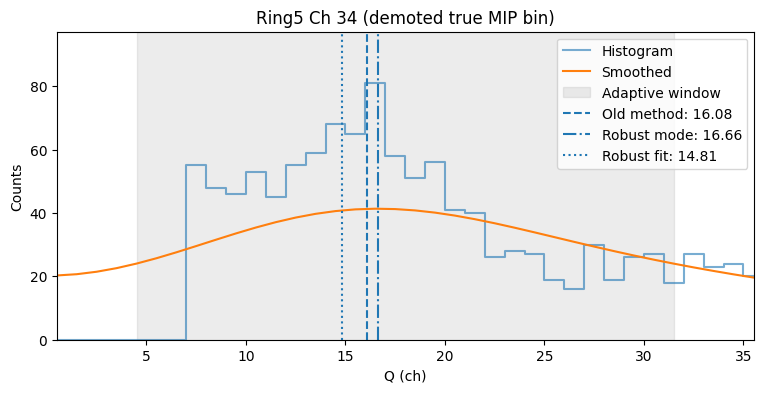

Ch 35: entries=1732


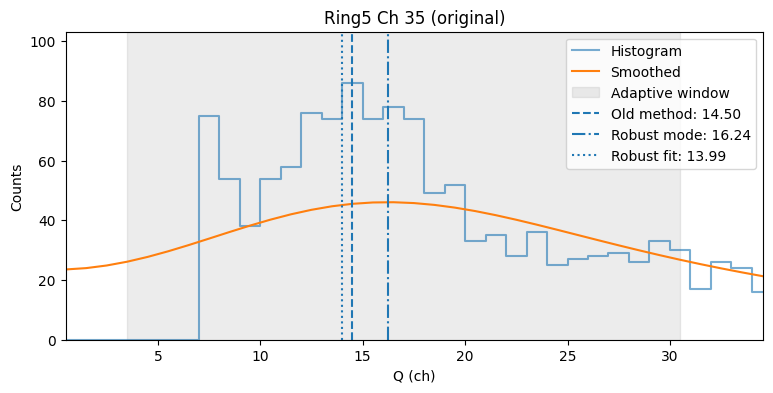

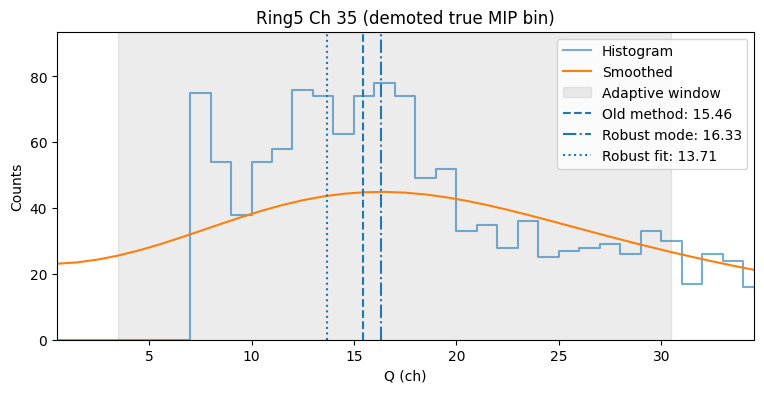

Ch 36: entries=1640


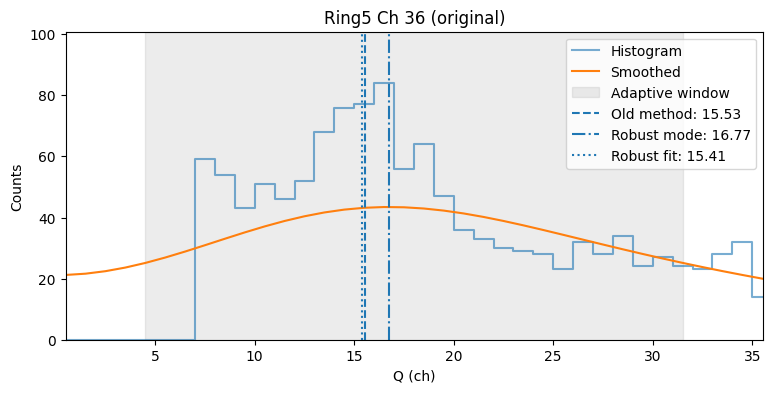

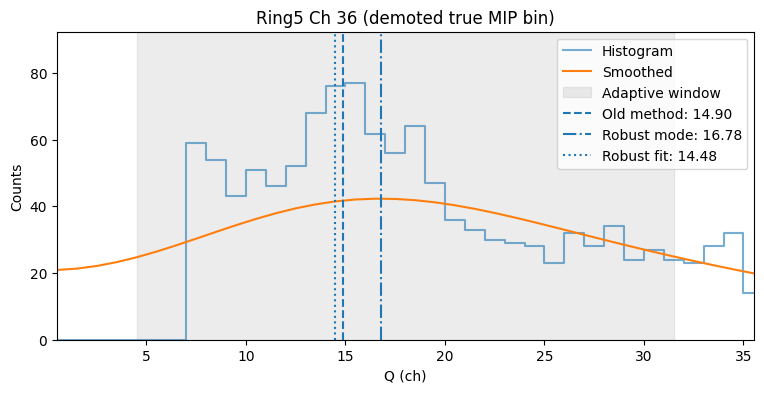

Ch 37: entries=1639


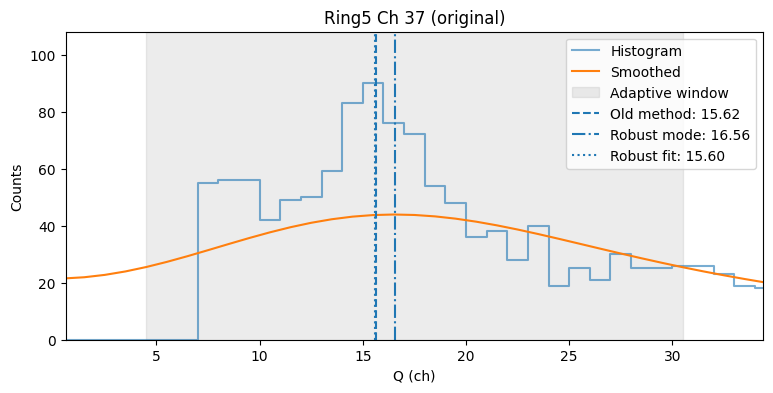

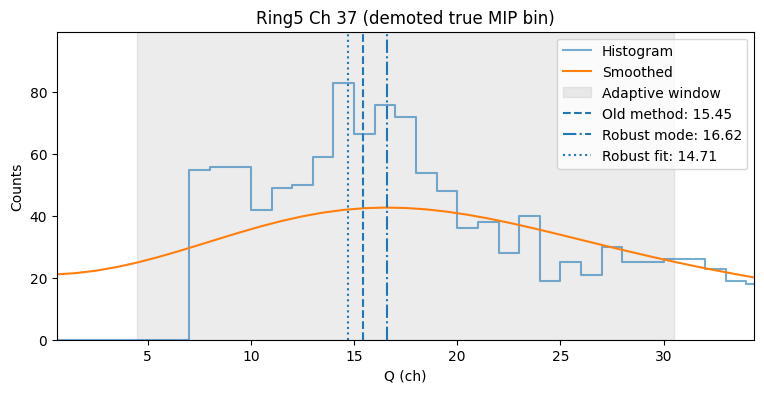

Ch 38: entries=1646


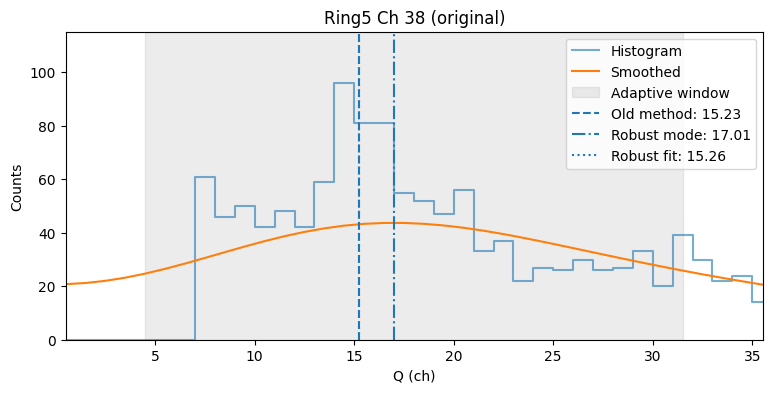

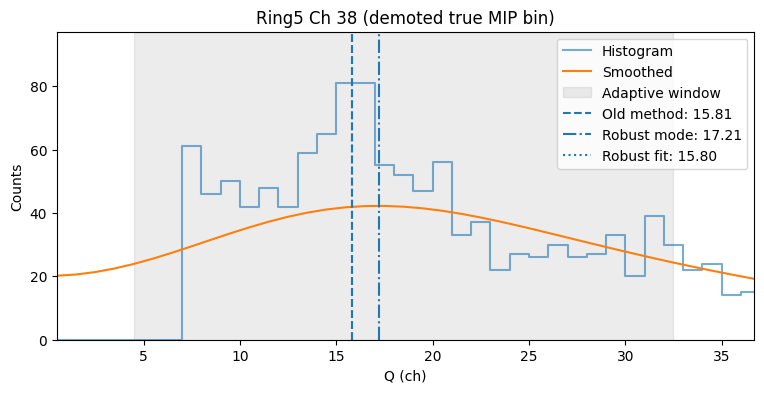

Ch 39: entries=1732


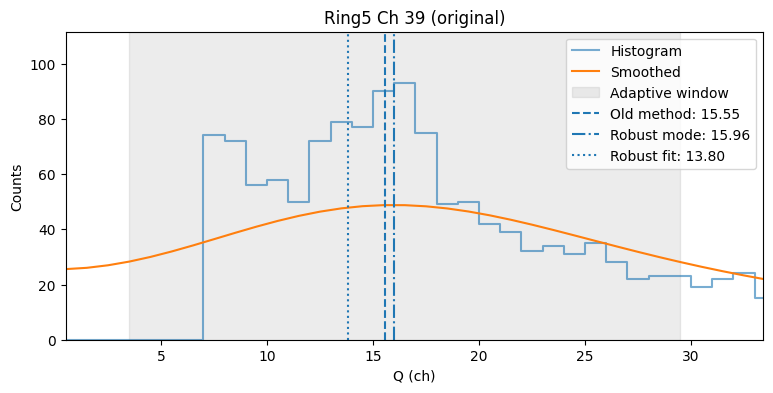

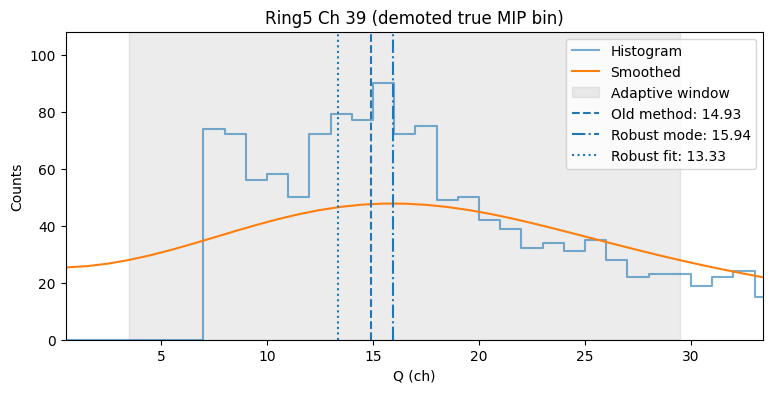

Ch 40: entries=1658


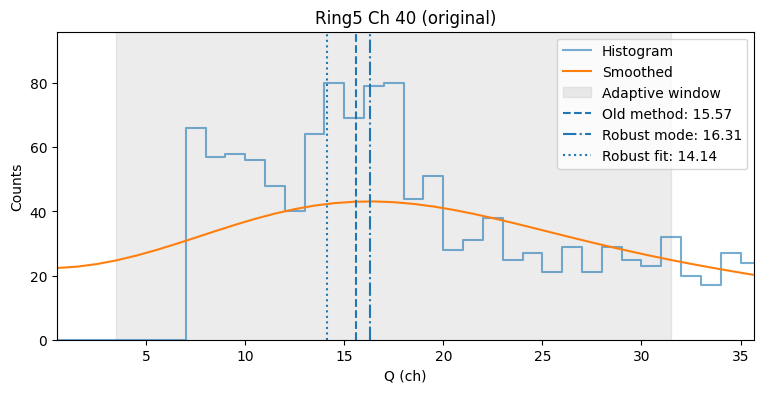

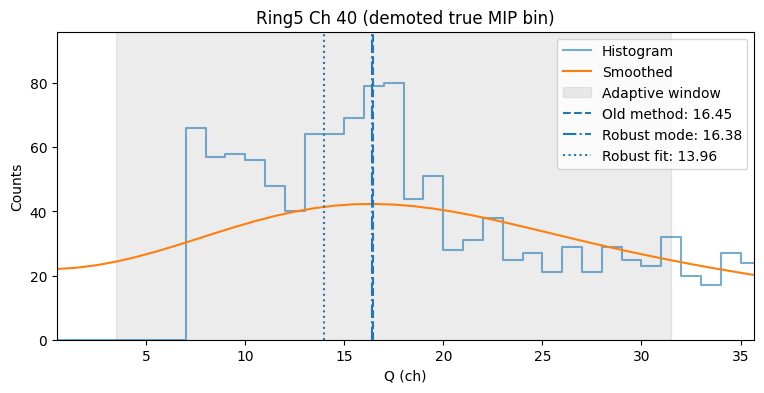

Ch 41: entries=1590


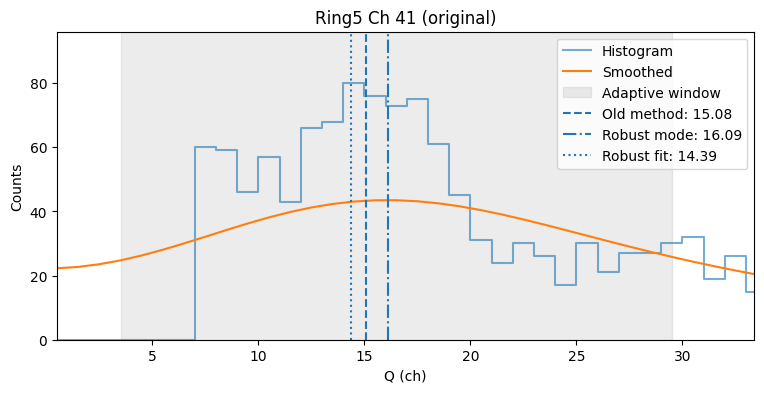

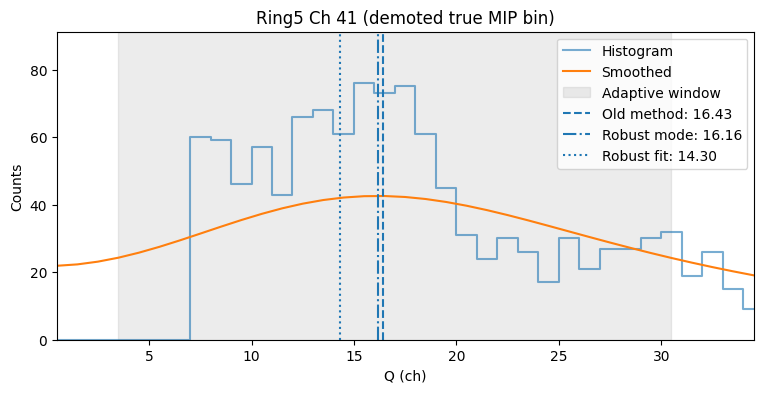

Ch 42: entries=1641


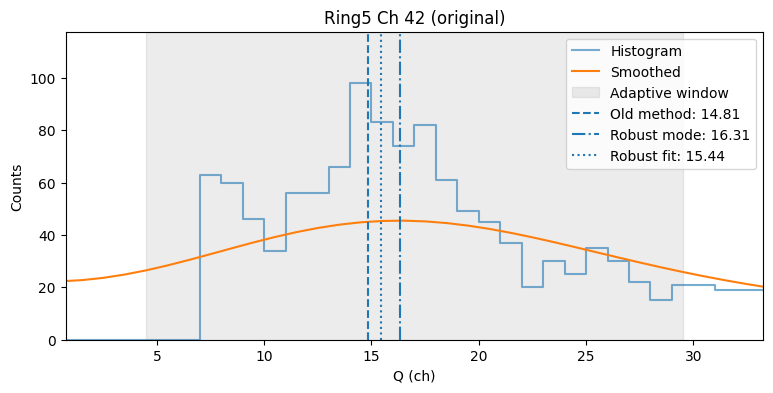

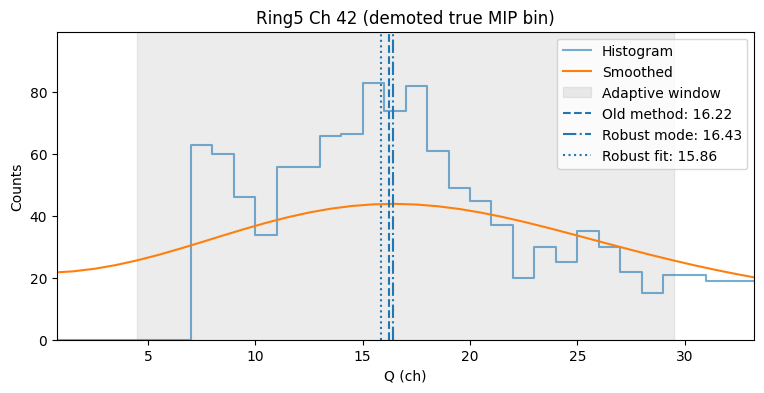

Ch 43: entries=1745


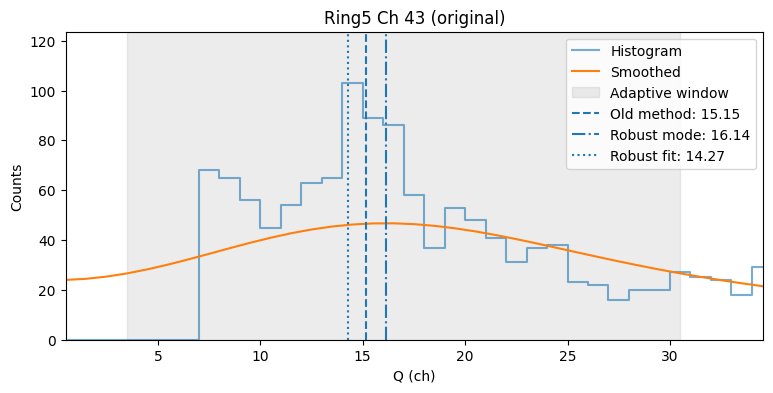

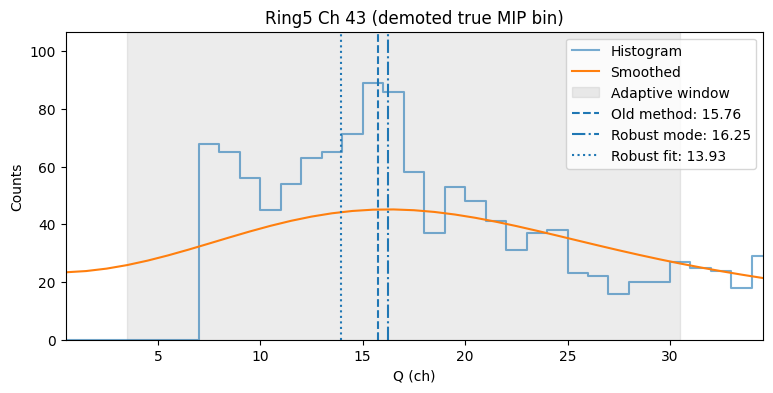

Ch 44: entries=1614


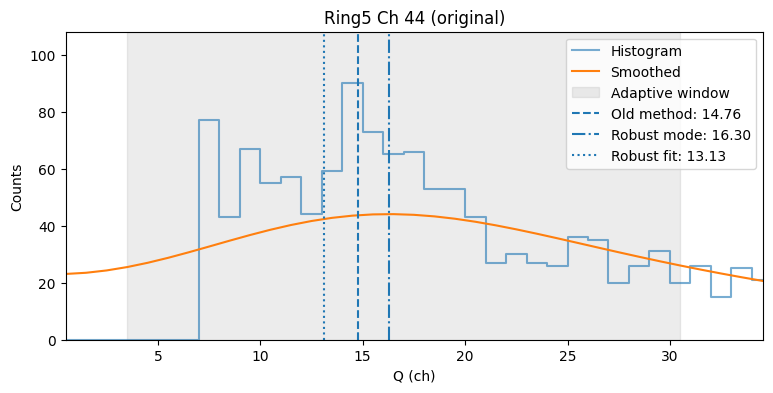

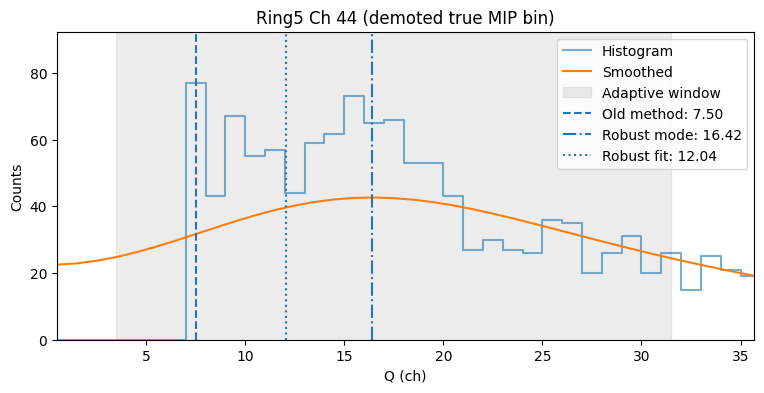

Ch 45: entries=1612


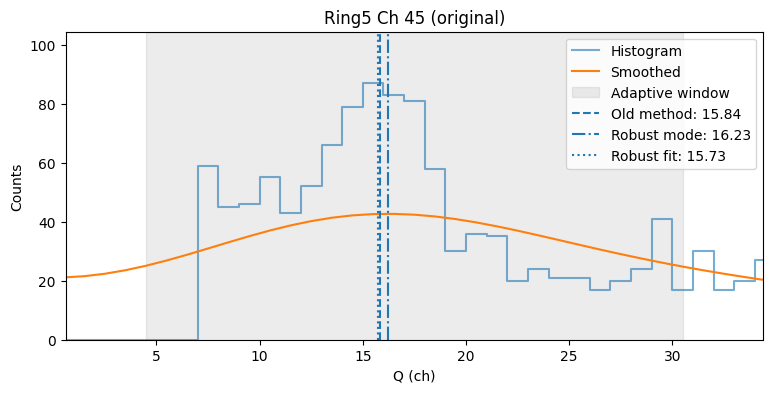

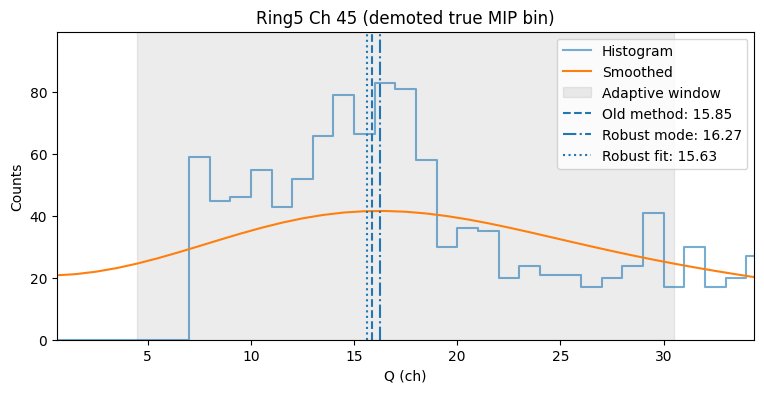

Ch 46: entries=1607


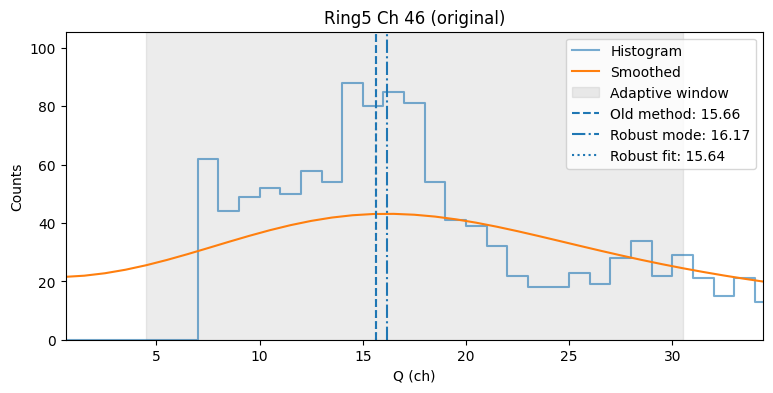

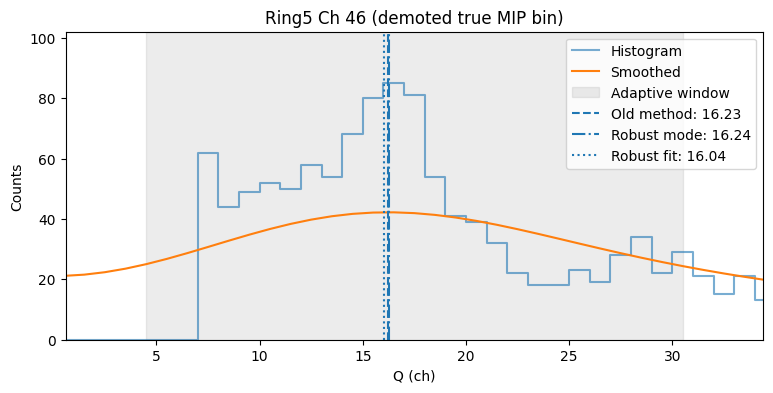

Ch 47: entries=1692


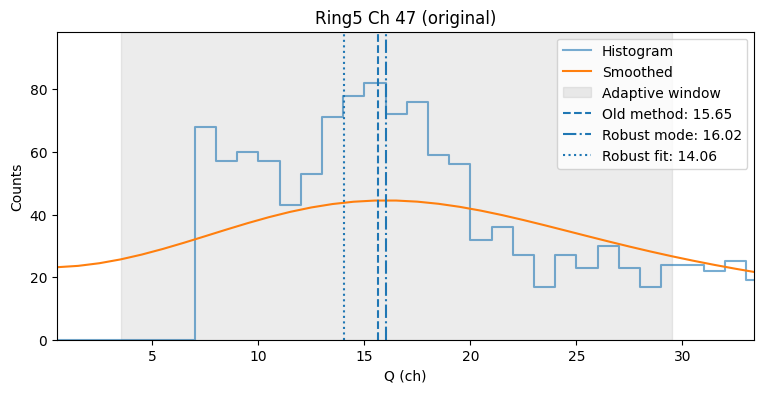

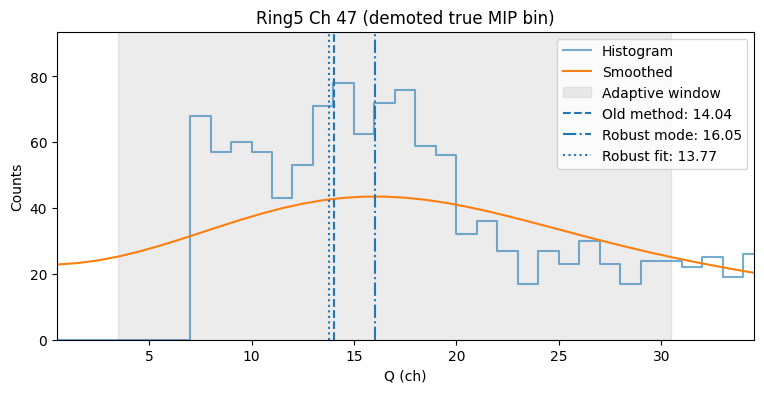

In [45]:
import matplotlib.pyplot as plt

for ch in RING5_CHANNELS:
    hist_ch, x_ch = hist_for_channel(tree, ch)
    if hist_ch.sum() == 0:
        print(f"Ch {ch}: no entries")
        continue

    print(f"Ch {ch}: entries={int(hist_ch.sum())}")

    # Original
    _ = plot_compare(
        hist_ch, x_ch,
        title=f"Ring5 Ch {ch} (original)",
        z=0.20,
        robust_kwargs={'qlow':0.10, 'qhigh':0.90, 'frac':0.60},
        fit_model='gauss',
        auto_zoom=True  # <-- quick zoom around adaptive window
    )

    # Distort the *true* MIP bin so it's no longer max (outlier case)
    hist_dem = demote_max_bin(hist_ch, target_ratio=0.80)
    _ = plot_compare(
        hist_dem, x_ch,
        title=f"Ring5 Ch {ch} (demoted true MIP bin)",
        z=0.20,
        robust_kwargs={'qlow':0.10, 'qhigh':0.90, 'frac':0.60},
        fit_model='gauss',
        auto_zoom=True
    )

### Notes
- The **robust method** removes the dependency on the *global* max bin and instead anchors on the **smoothed mode** inside robust quantiles. This tolerates cases where the true MIP peak is suppressed or a neighboring bin is artificially boosted.
- For a more physics-faithful fit, you can switch `fit_model='exgauss'` (exponentially modified Gaussian) which captures right-skewed peaks better than a pure Gaussian. The reported MIP then is the **mode** of the fitted exGaussian.
- You can tweak the smoothing `sigma_bins`, quantile bounds `(qlow,qhigh)`, and adaptive-window fraction `frac` for your dataset.
- To emulate other artifacts, use `spillover_shift()` to add neighbor leakage/bit-shifts.


# FV0 Ring-5 MIP Spectra — Robust Outlier (Anomaly) Detection

**Goal.** Detect channels whose **amplitude spectrum** (MIP distribution) is *abnormal* due to
electronics artifacts or miscalibration — e.g., **shifted** MIP peak, **suppressed** peak, or **broadened**/noisy shape.

We proceed in four steps:

1. **Load** a single MC ROOT file and build **per-channel** histograms for Ring-5 (channels 32–48, 1-indexed).
2. **Distort** histograms to synthesize realistic anomalies:
   - gain **shift** (multiplicative/additive),
   - **peak suppression** (the true MIP bin is no longer the max),
   - **broadening**/**hot-channel** noise injection.
3. **Extract features** from each spectrum:
   - robust MIP peak (mode-based), “old” peak (max-bin windowed Gaussian),
   - statistical moments, quantiles, prominence/width, distance to a template spectrum (JS divergence).
4. **Detect anomalies** using several methods:  
   Z-score thresholding, **Isolation Forest**, **One-Class SVM**, and **PCA+Mahalanobis**.

We evaluate with **ground-truth labels** (original vs. distorted) and report **ROC-AUC, PR-AUC, F1** and timing.

In [48]:
# --- Core scientific stack ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from time import perf_counter

# ROOT reading
import uproot, awkward as ak

# SciPy
from scipy import signal, stats
from scipy.optimize import curve_fit, least_squares
from scipy.ndimage import gaussian_filter1d

# ML (optional, but recommended)
try:
    from sklearn.ensemble import IsolationForest
    from sklearn.svm import OneClassSVM
    from sklearn.decomposition import PCA
    from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, f1_score
    SKLEARN_AVAILABLE = True
except Exception as e:
    print("scikit-learn not available, ML methods will be skipped:", e)
    SKLEARN_AVAILABLE = False

# --- Plot style ---
plt.rcParams.update({
    "figure.figsize": (8,4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

# --- Paths & constants ---
IN_DIR = "/home/mvishiu11/Desktop/CERN/LHC-aging-analysis/data/physicsROOT/"
ROOT_FILE = next(Path(IN_DIR).glob("*.root"))  # single file
print("Using ROOT file:", ROOT_FILE)

HIST_BINS = 4100
HIST_RANGE = (0, 4100)
RING5_CHANNELS = list(range(32, 49))  # 1-indexed inclusive: 32..48

# Helpful tiny utility
def timer():
    """Context-like timer."""
    t0 = perf_counter()
    return lambda: perf_counter() - t0

Using ROOT file: /home/mvishiu11/Desktop/CERN/LHC-aging-analysis/data/physicsROOT/fv0digits.root


In [50]:
f = uproot.open(ROOT_FILE)
print("Top-level keys:", f.keys())

tree = f["o2sim/FV0DigitCh"]
print("Tree keys (truncated):", list(tree.keys())[:12])

def first_existing(tree, candidates):
    keys = set(tree.keys())
    for c in candidates:
        if c in keys:
            return c
    raise KeyError(f"None present: {candidates}")

CH_BRANCH  = first_existing(tree, ["FV0DigitCh.ChId"])
AMP_BRANCH = first_existing(tree, ["FV0DigitCh.QTCAmpl", "FVD0igitCh.OTCAmpl", "FV0DigitCh.getAmp0()"])  # last just in case
print("Using branches:", CH_BRANCH, AMP_BRANCH)

def hist_for_channel(tree, ch_id_1idx, bins=HIST_BINS, rng=HIST_RANGE):
    ch_ak  = tree[CH_BRANCH].array(library="ak")
    amp_ak = tree[AMP_BRANCH].array(library="ak")
    ch  = ak.to_numpy(ak.flatten(ch_ak))
    amp = ak.to_numpy(ak.flatten(amp_ak))
    sel = (ch == ch_id_1idx)
    vals = amp[sel]
    h, edges = np.histogram(vals, bins=bins, range=rng)
    centers = 0.5*(edges[:-1] + edges[1:])
    return h.astype(float), centers

# sanity check for one channel
h0, x0 = hist_for_channel(tree, RING5_CHANNELS[0])
print(f"Ring5 ch {RING5_CHANNELS[0]}: entries={int(h0.sum())}")

Top-level keys: ['o2sim;1']
Tree keys (truncated): ['FV0DigitCh.ChId', 'FV0DigitCh.ChainQTC', 'FV0DigitCh.CFDTime', 'FV0DigitCh.QTCAmpl']
Using branches: FV0DigitCh.ChId FV0DigitCh.QTCAmpl
Ring5 ch 32: entries=1703


In [51]:
def cdf_from_hist(hist, edges):
    # normalized CDF at edges; edges length = bins+1
    c = np.concatenate([[0.0], np.cumsum(hist)])
    c = c / c[-1] if c[-1] > 0 else c
    return c

def resample_hist_via_cdf(hist, edges, map_x):
    """
    Given original histogram (hist, edges) that represents counts over x,
    and a *mapping* map_x(x_new) -> x_old,
    return new histogram on the SAME edges after the mapping.
    Counts in new bin [e_i, e_{i+1}] = N * (F(map_x(e_{i+1})) - F(map_x(e_i))).
    """
    N = hist.sum()
    if N == 0: return hist.copy()
    F_edges = cdf_from_hist(hist, edges)  # CDF defined on edges
    F = lambda x: np.interp(x, edges, F_edges, left=0.0, right=1.0)
    new = np.empty_like(hist, dtype=float)
    for i in range(len(hist)):
        a, b = edges[i], edges[i+1]
        new[i] = N * (F(map_x(b)) - F(map_x(a)))
    return new

def scale_x(hist, edges, s):
    """Multiplicative gain change: x_new = s * x_old  => map_x(x_new)=x_new/s."""
    return resample_hist_via_cdf(hist, edges, map_x=lambda x: x/s)

def shift_x(hist, edges, delta):
    """Additive shift: x_new = x_old + delta => map_x(x_new)=x_new - delta."""
    return resample_hist_via_cdf(hist, edges, map_x=lambda x: x - delta)

def broaden(hist, sigma_bins=5):
    """Gaussian broadening (simulates noise)."""
    return gaussian_filter1d(hist.astype(float), sigma=sigma_bins)

def inject_hot(hist, x, thr=80, extra=0.2):
    """Add hot-trigger counts near threshold: add 'extra' fraction of total into first bins up to thr."""
    h = hist.astype(float).copy()
    idx = np.where(x <= thr)[0]
    add_total = extra * h.sum()
    if len(idx) > 0 and add_total > 0:
        add = np.zeros_like(h)
        add[idx] = 1.0
        add *= add_total / add.sum()
        h += add
    return h

def demote_true_peak_bin(hist, x, target_ratio=0.80):
    """Lower the *true* MIP bin (from robust-mode) so it is not the maximum anymore."""
    _, idx, y_s, _ = robust_mode_from_smoothed(hist, x)
    if idx is None: return hist.copy()
    h = hist.astype(float).copy()
    tmp = h.copy(); tmp[idx] = -np.inf
    i2 = int(np.argmax(tmp)); v2 = h[i2]
    newv = min(h[idx], target_ratio*v2)
    h[idx] = min(newv, 0.99*v2)
    return h

Loaded 16 ring-5 channels with entries.


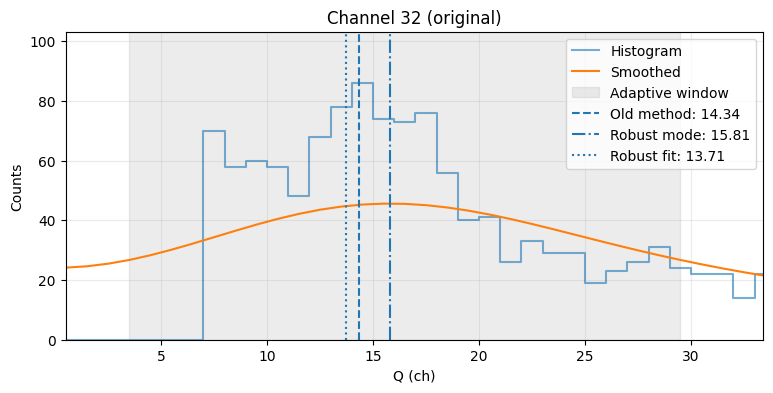

In [52]:
# Collect originals
edges = np.linspace(HIST_RANGE[0], HIST_RANGE[1], HIST_BINS+1)
xcent = 0.5*(edges[:-1]+edges[1:])

orig = {}
for ch in RING5_CHANNELS:
    h,_ = hist_for_channel(tree, ch)
    if h.sum()>0:
        orig[ch] = h
print(f"Loaded {len(orig)} ring-5 channels with entries.")

# Build a reference "template" (median normalized shape across channels)
def normalize(h):
    s = h.sum()
    return h/s if s>0 else h

stack = np.stack([normalize(h) for h in orig.values()], axis=0) if len(orig) else np.zeros((0,len(xcent)))
template = np.median(stack, axis=0) if len(stack) else np.zeros_like(xcent)

# quick look for one channel
ch0 = next(iter(orig))
_ = plot_compare(orig[ch0], xcent, f"Channel {ch0} (original)", robust_kwargs={'frac':0.60}, auto_zoom=True)

In [53]:
def js_divergence(p, q, eps=1e-12):
    p = np.clip(p, eps, None); p = p/p.sum()
    q = np.clip(q, eps, None); q = q/q.sum()
    m = 0.5*(p+q)
    return 0.5*(stats.entropy(p, m) + stats.entropy(q, m))

def width_at_fraction(y_s, x, frac=0.6):
    idx = np.argmax(y_s)
    L,R = adaptive_window_from_smoothed(x, y_s, idx, frac)
    return x[R]-x[L]

def extract_features(h, x, template_norm, label, channel, variant, z=0.2):
    # Old peak
    old,_,_ = old_method_gaussian(h, x, z=z)
    # Robust peak/mode
    res = robust_method(h, x, frac=0.60)
    r_mode, r_fit = res['mip_mode'], res['mip_fit']
    y_s = res['y_smooth'] if res['y_smooth'] is not None else smooth_counts(h)
    # Moments / quantiles on counts-as-sample proxy (weight by counts)
    idx_non0 = h>0
    mean = np.average(x[idx_non0], weights=h[idx_non0]) if idx_non0.any() else np.nan
    var  = np.average((x[idx_non0]-mean)**2, weights=h[idx_non0]) if idx_non0.any() else np.nan
    std  = np.sqrt(var) if var==var else np.nan
    # quantiles from empirical CDF
    cum = np.cumsum(h); tot = h.sum()
    q = lambda p: np.interp(p*tot, cum, x)
    q10 = q(0.10) if tot>0 else np.nan
    q50 = q(0.50) if tot>0 else np.nan
    q90 = q(0.90) if tot>0 else np.nan
    # shape: width and prominence proxy
    w60 = width_at_fraction(y_s, x, 0.60)
    prom = np.max(signal.peak_prominences(y_s, [np.argmax(y_s)])[0]) if y_s.max()>0 else 0.0
    # distances to template
    jsd = js_divergence(normalize(h), template_norm) if template_norm.sum()>0 else np.nan
    return {
        "channel": channel, "variant": variant, "label": label,  # 0=original,1=anomaly
        "old_peak": old, "robust_mode": r_mode, "robust_fit": r_fit,
        "mean": mean, "std": std, "q10": q10, "q50": q50, "q90": q90,
        "w60": w60, "prom": prom, "jsd_to_template": jsd,
    }

In [54]:
rows = []

# Distortion settings (tweak freely)
gain_scales   = [0.85, 1.15]   # multiplicative gain error
add_shifts    = [ -80, +80 ]   # additive ADC shift
broaden_sigmas= [4, 8]         # gaussian filter in bins
hot_levels    = [0.15]         # 15% extra counts near threshold
suppress_r    = [0.80]         # demote true peak to 80% of next max

for ch,h in orig.items():
    # original
    rows.append(extract_features(h, xcent, template, label=0, channel=ch, variant="original"))

    # scaled gain
    for s in gain_scales:
        h_s = scale_x(h, edges, s)
        rows.append(extract_features(h_s, xcent, template, label=1, channel=ch, variant=f"scale_{s}"))

    # additive shift
    for d in add_shifts:
        h_d = shift_x(h, edges, d)
        rows.append(extract_features(h_d, xcent, template, label=1, channel=ch, variant=f"shift_{d}"))

    # broadened/noisy
    for sg in broaden_sigmas:
        h_b = broaden(h, sigma_bins=sg)
        rows.append(extract_features(h_b, xcent, template, label=1, channel=ch, variant=f"broaden_{sg}"))

    # hot near threshold
    for hl in hot_levels:
        h_hot = inject_hot(h, xcent, thr=80, extra=hl)
        rows.append(extract_features(h_hot, xcent, template, label=1, channel=ch, variant=f"hot_{hl}"))

    # peak suppression (true MIP not max)
    for rr in suppress_r:
        h_sup = demote_true_peak_bin(h, xcent, target_ratio=rr)
        rows.append(extract_features(h_sup, xcent, template, label=1, channel=ch, variant=f"suppress_{rr}"))

df = pd.DataFrame(rows)
print("Dataset size:", df.shape)
df.head()

Dataset size: (144, 14)


,channel,variant,label,old_peak,robust_mode,robust_fit,mean,std,q10,q50,q90,w60,prom,jsd_to_template
0,32,original,0,14.336425,15.813012,13.712778,36.936289,52.849707,9.205000,19.658537,71.240000,26.0,21.441934,0.025490
1,32,scale_0.85,1,12.294323,13.684195,11.717680,31.399762,44.920245,7.753475,16.642581,60.477419,27.0,15.826796,0.047554
2,32,scale_1.15,1,17.139714,17.780247,15.795266,42.479627,60.776077,10.663475,22.682317,82.044565,25.0,25.274592,0.042952
3,32,shift_-80,1,5.500000,5.500000,5.503112,87.743243,103.864687,5.466667,49.500000,220.700000,25.0,0.000000,0.328788
4,32,shift_80,1,93.644589,95.957433,93.693245,116.936289,52.849707,89.205000,99.658537,151.240000,24.0,45.443381,0.623948


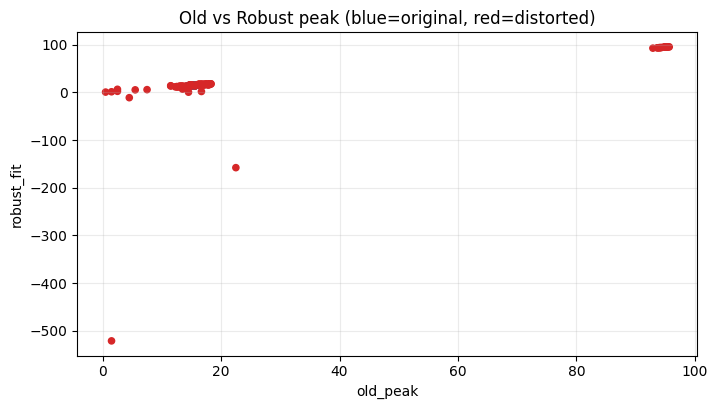

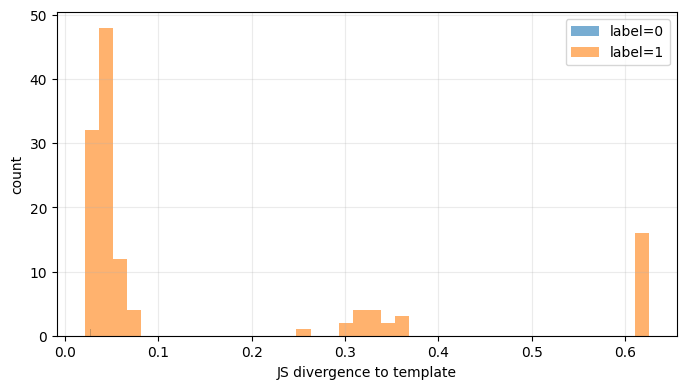

In [55]:
# Peak comparison
ax = df.plot.scatter(x="old_peak", y="robust_fit", c=(df['label'].map({0:'tab:blue',1:'tab:red'})),
                     title="Old vs Robust peak (blue=original, red=distorted)")
plt.show()

# Distance to template
plt.figure(); 
for lbl,sub in df.groupby('label'):
    plt.hist(sub['jsd_to_template'].fillna(0), bins=40, alpha=0.6, label=f"label={lbl}")
plt.xlabel("JS divergence to template"); plt.ylabel("count"); plt.legend(); plt.show()

In [56]:
feature_cols = [
    "robust_fit", "robust_mode", "old_peak",
    "mean", "std", "q10", "q50", "q90",
    "w60", "prom", "jsd_to_template"
]
df_feat = df.dropna(subset=feature_cols).reset_index(drop=True)
X = df_feat[feature_cols].values
y = df_feat["label"].values.astype(int)

# Train only on originals (unsupervised setting)
X_train = df_feat[df_feat["label"]==0][feature_cols].values
X_all   = X

results = []

# --- 9.1 Z-score threshold (simple baseline) ---
mu = X_train.mean(axis=0); sd = X_train.std(axis=0) + 1e-9
z  = np.abs((X_all - mu)/sd)
score_z = z.max(axis=1)  # max deviation across features
auc_z = roc_auc_score(y, score_z) if len(np.unique(y))>1 else np.nan
ap_z  = average_precision_score(y, score_z) if len(np.unique(y))>1 else np.nan
results.append(("Zscore(max)", auc_z, ap_z, score_z))

# --- 9.2 PCA + Mahalanobis ---
pca = PCA(n_components=min(6, X_train.shape[1]))
pca.fit(X_train)
Z_all = pca.transform(X_all)
muZ = Z_all[y==0].mean(axis=0)
covZ = np.cov(Z_all[y==0].T) + 1e-6*np.eye(Z_all.shape[1])
invC = np.linalg.pinv(covZ)
md2 = np.einsum("ij,jk,ik->i", (Z_all-muZ), invC, (Z_all-muZ))   # squared Mahalanobis
score_md = md2
auc_md = roc_auc_score(y, score_md); ap_md = average_precision_score(y, score_md)
results.append(("PCA+Mahalanobis", auc_md, ap_md, score_md))

# --- 9.3 Isolation Forest ---
if SKLEARN_AVAILABLE:
    iso = IsolationForest(n_estimators=300, contamination=0.1, random_state=0)
    iso.fit(X_train)
    # sklearn returns higher = more normal; make higher=more anomalous
    s_if = -iso.score_samples(X_all)
    auc_if = roc_auc_score(y, s_if); ap_if = average_precision_score(y, s_if)
    results.append(("IsolationForest", auc_if, ap_if, s_if))

# --- 9.4 One-Class SVM ---
if SKLEARN_AVAILABLE:
    oc = OneClassSVM(kernel="rbf", nu=0.10, gamma="scale")
    oc.fit(X_train)
    s_oc = -oc.decision_function(X_all).ravel()
    auc_oc = roc_auc_score(y, s_oc); ap_oc = average_precision_score(y, s_oc)
    results.append(("OneClassSVM", auc_oc, ap_oc, s_oc))

# Summary table
summary = pd.DataFrame([(name, f"{auc:.3f}", f"{ap:.3f}") for (name,auc,ap,_) in results],
                       columns=["Method","ROC-AUC","PR-AUC"])
summary

,Method,ROC-AUC,PR-AUC
0,Zscore(max),0.935,0.992
1,PCA+Mahalanobis,0.934,0.992
2,IsolationForest,0.911,0.988
3,OneClassSVM,0.846,0.980


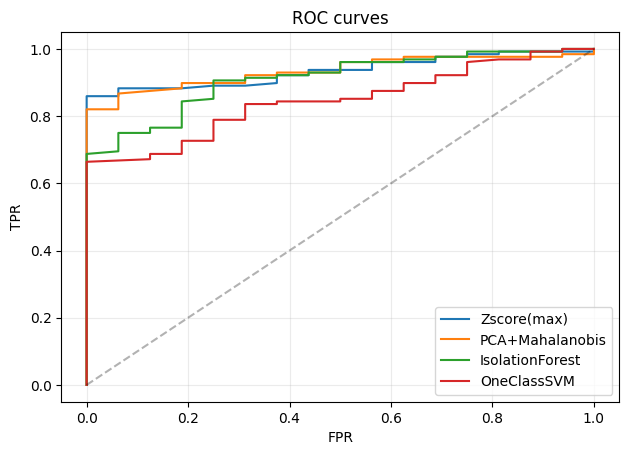

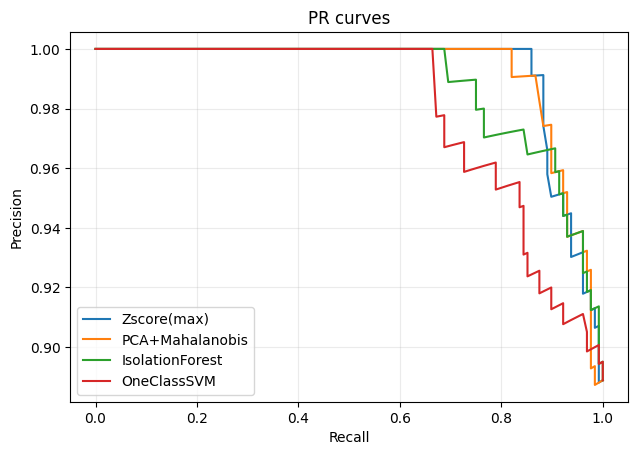

,Method,ROC-AUC,PR-AUC,F1*,thr,TP,FP,TN,FN
0,Zscore(max),0.934570,0.991981,0.947761,1.281793,127,14,2,1
1,PCA+Mahalanobis,0.934082,0.991887,0.950570,3.990309,125,11,5,3
2,IsolationForest,0.910645,0.988217,0.951311,0.461350,127,13,3,1
3,OneClassSVM,0.845947,0.979584,0.944649,-0.037315,128,16,0,0


In [57]:
def best_f1(y_true, scores):
    P, R, T = precision_recall_curve(y_true, scores)
    f1s = 2*P*R/(P+R+1e-12)
    i = int(np.nanargmax(f1s))
    return f1s[i], T[i-1] if i>0 else T[0], P[i], R[i]

# Plot ROC + PR for each method
plt.figure(figsize=(7.2,4.8))
for (name,_,_,scores) in results:
    fpr, tpr, _ = roc_curve(y, scores)
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1],[0,1],'k--',alpha=0.3)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC curves"); plt.legend(); plt.show()

plt.figure(figsize=(7.2,4.8))
for (name,_,_,scores) in results:
    P,R,_ = precision_recall_curve(y, scores)
    plt.plot(R, P, label=name)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR curves"); plt.legend(); plt.show()

# Confusion for each at best F1
conf_rows = []
for (name, auc, ap, scores) in results:
    f1, thr, P, R = best_f1(y, scores)
    yhat = (scores >= thr).astype(int)
    tp = int(((y==1)&(yhat==1)).sum())
    fp = int(((y==0)&(yhat==1)).sum())
    tn = int(((y==0)&(yhat==0)).sum())
    fn = int(((y==1)&(yhat==0)).sum())
    conf_rows.append([name, float(auc), float(ap), float(f1), thr, tp, fp, tn, fn])

pd.DataFrame(conf_rows, columns=["Method","ROC-AUC","PR-AUC","F1*","thr","TP","FP","TN","FN"])

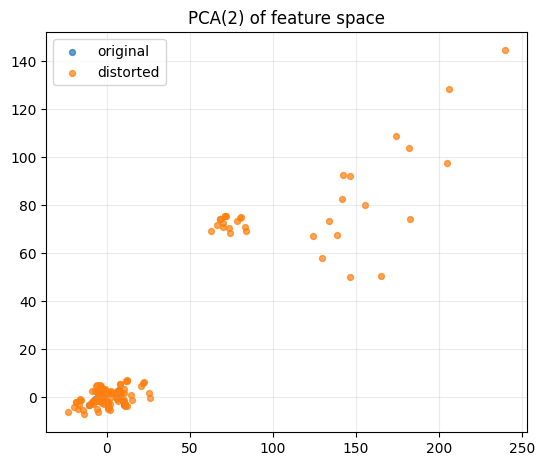

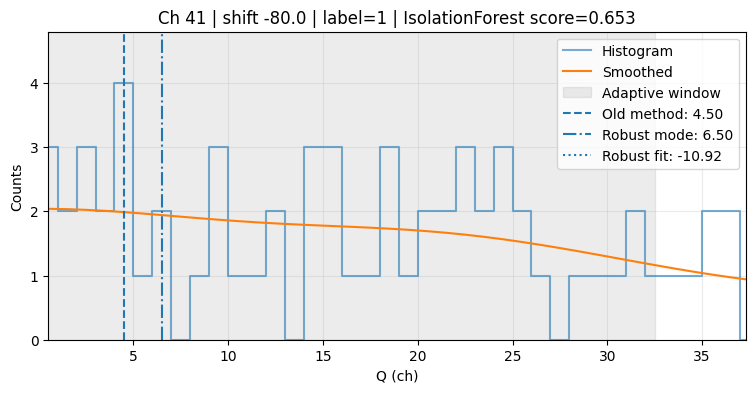

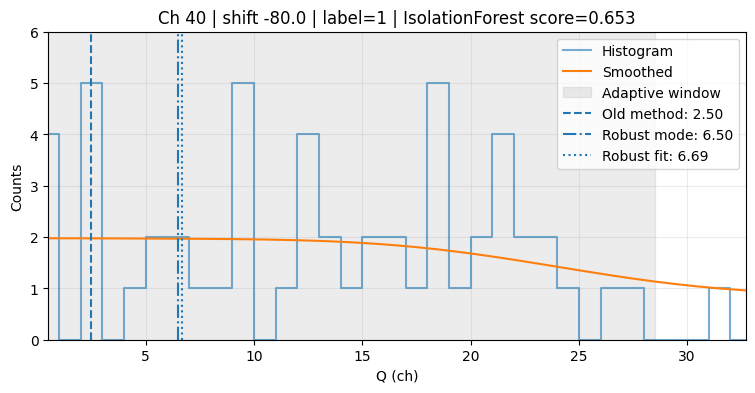

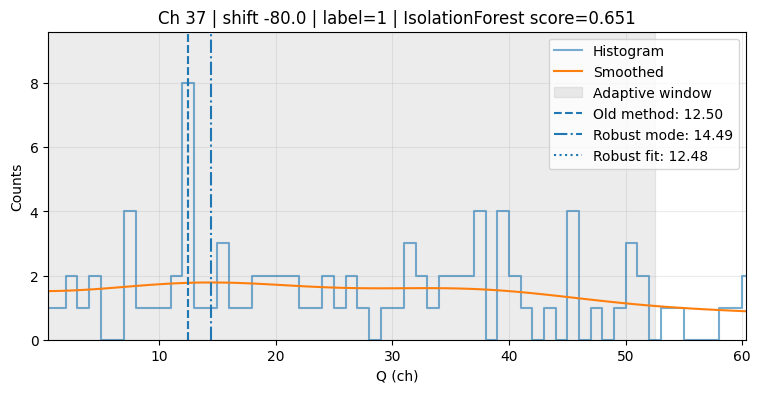

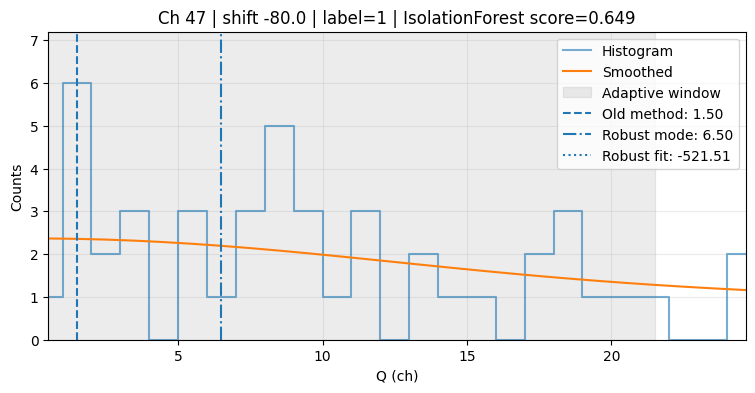

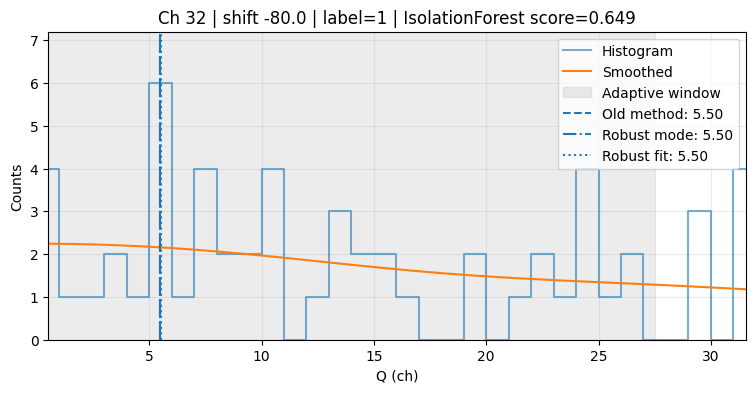

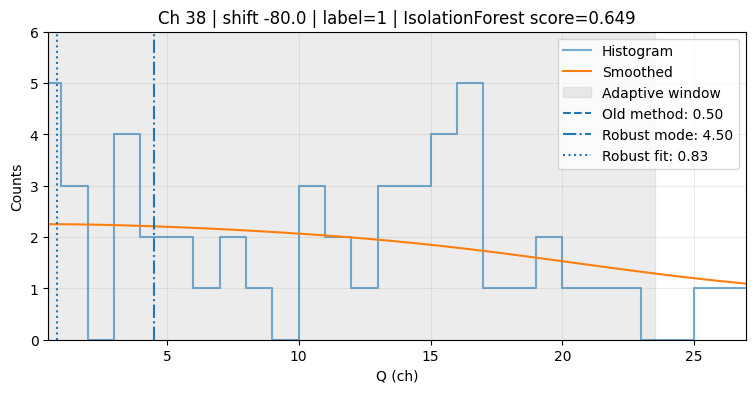

In [58]:
# 2D PCA for visualization only
p2 = PCA(n_components=2).fit(X_train)
Z2 = p2.transform(X_all)
plt.figure(figsize=(6.2,5.2))
plt.scatter(Z2[y==0,0], Z2[y==0,1], s=18, alpha=0.7, label="original")
plt.scatter(Z2[y==1,0], Z2[y==1,1], s=18, alpha=0.7, label="distorted")
plt.title("PCA(2) of feature space"); plt.legend(); plt.show()

# Show a few top-scoring anomalies (by Isolation Forest if available, else by PCA-MD)
name, _, _, scores_ref = (results[2] if SKLEARN_AVAILABLE else results[1])
idx_sorted = np.argsort(scores_ref)[::-1]  # descending anomaly
top_idx = idx_sorted[:6]

for i in top_idx:
    r = df_feat.iloc[i]
    ch, var, lbl = r["channel"], r["variant"], r["label"]
    # regenerate the histogram to plot
    h = orig[ch]
    hplot = None
    if var.startswith("scale_"):
        s = float(var.split("_")[1]); hplot = scale_x(h, edges, s)
        t = f"scale {s}"
    elif var.startswith("shift_"):
        d = float(var.split("_")[1]); hplot = shift_x(h, edges, d)
        t = f"shift {d}"
    elif var.startswith("broaden_"):
        sg = float(var.split("_")[1]); hplot = broaden(h, sigma_bins=sg)
        t = f"broaden {sg}"
    elif var.startswith("hot_"):
        hl = float(var.split("_")[1]); hplot = inject_hot(h, xcent, extra=hl)
        t = f"hot {hl}"
    elif var.startswith("suppress_"):
        rr = float(var.split("_")[1]); hplot = demote_true_peak_bin(h, xcent, target_ratio=rr)
        t = f"suppress {rr}"
    else:
        hplot = h; t = "original"

    _ = plot_compare(hplot, xcent,
                     title=f"Ch {ch} | {t} | label={lbl} | {name} score={scores_ref[i]:.3f}",
                     robust_kwargs={'frac':0.60}, auto_zoom=True)

# POC — Synthetic Anomaly Detection for 1D Spectra (Detector-Agnostic)

**Goal.** Demonstrate anomaly detection on realistic synthetic spectra (MIP-like), without relying on any “robust peak fitting.”  
We will:
1) Generate synthetic per-channel spectra (exGaussian / Landau-like).
2) Inject anomalies: gain shift, additive shift, broadening, hot-threshold, peak suppression, dead channel, bimodal mix.
3) Extract **simple, explainable features** (no robust peak fitting).
4) Compare detectors trained on normal data only:
   - Z-score thresholding (baseline),
   - PCA + Mahalanobis distance,
   - Isolation Forest,
   - One-Class SVM,
   - (optional) LOF novelty detection.

We report ROC-AUC, PR-AUC, best-F1, and show diagnostic plots (feature scatter, PCA view, exemplar spectra).

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from time import perf_counter

from scipy import stats, signal
from scipy.ndimage import gaussian_filter1d

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)

plt.rcParams.update({
    "figure.figsize": (8.5, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False
})

rng = np.random.default_rng(42)

# Histogram axis (generic ADC / amplitude scale)
HIST_BINS  = 4100
HIST_RANGE = (0, 4100)
edges = np.linspace(HIST_RANGE[0], HIST_RANGE[1], HIST_BINS + 1)
xcent = 0.5 * (edges[:-1] + edges[1:])

def timer():
    t0 = perf_counter()
    return lambda: perf_counter() - t0

In [73]:
def _get_rng(rng):
    if rng is None:
        return np.random.default_rng()
    if isinstance(rng, (int, np.integer)):
        return np.random.default_rng(int(rng))
    return rng  # assume it's already a Generator

# --------- Synthetic generator for "normal" spectra ----------
def synth_exgauss_hist(n_events=30000, mpv=1500, xi=150, K=1.5, noise_sigma=3.0, threshold=40, rng=None):
    """
    Generate Landau-like (exGaussian) spectrum with optional zero-suppression threshold.
    - K: shape, scale ~ xi/3, loc ~ mpv - K*scale -> MPV near 'mpv'
    - Add small Gaussian noise per sample; clip to histogram range.
    Returns counts per bin.
    """
    r = np.random.default_rng() if rng is None else _get_rng(rng)
    scale = xi / 3.0
    loc = mpv - K * scale
    x = stats.exponnorm.rvs(K, loc=loc, scale=scale, size=n_events, random_state=r)
    x = x + r.normal(0, noise_sigma, size=n_events)
    if threshold is not None:
        x = x[x >= threshold]
    x = np.clip(x, HIST_RANGE[0], HIST_RANGE[1])
    h, _ = np.histogram(x, bins=HIST_BINS, range=HIST_RANGE)
    return h.astype(float)

# --------- CDF-based remapping utilities for realistic “gain” & “shift” ----------
def _cdf_from_hist(hist, edges):
    c = np.concatenate([[0.0], np.cumsum(hist)])
    return c / c[-1] if c[-1] > 0 else c

def _resample_hist_via_cdf(hist, edges, map_x):
    N = float(hist.sum())
    if N == 0: return hist.copy()
    F_edges = _cdf_from_hist(hist, edges)
    F = lambda x: np.interp(x, edges, F_edges, left=0.0, right=1.0)
    out = np.empty_like(hist, dtype=float)
    for i in range(len(hist)):
        a, b = edges[i], edges[i+1]
        out[i] = N * (F(map_x(b)) - F(map_x(a)))
    return out

def gain_scale(hist, s):
    """x_new = s * x_old -> map_x(x_new) = x_new / s"""
    return _resample_hist_via_cdf(hist, edges, map_x=lambda x: x / s)

def add_shift(hist, d):
    """x_new = x_old + d -> map_x(x_new) = x_new - d"""
    return _resample_hist_via_cdf(hist, edges, map_x=lambda x: x - d)

# --------- Other anomaly morphisms ----------
def broaden(hist, sigma_bins=6):
    """Convolutional broadening (noise / shaping)."""
    return gaussian_filter1d(hist.astype(float), sigma=sigma_bins)

def hot_threshold(hist, frac=0.25, thr=80):
    """Inject extra counts below 'thr' to mimic hot channel / trigger noise."""
    h = hist.astype(float).copy()
    idx = np.where(xcent <= thr)[0]
    add_total = frac * h.sum()
    if len(idx) and add_total > 0:
        add = np.zeros_like(h); add[idx] = 1.0
        add *= add_total / add.sum()
        h += add
    return h

def dead_like(n_events=10000, mu=25, sigma=10):
    """Pedestal-only dead channel (no MIP)."""
    r = np.random.default_rng() if rng is None else _get_rng(rng)
    x = r.normal(mu, sigma, size=n_events)
    x = np.clip(x, HIST_RANGE[0], HIST_RANGE[1])
    h, _ = np.histogram(x, bins=HIST_BINS, range=HIST_RANGE)
    return h.astype(float)

def suppress_peak_bin(hist, target_ratio=0.8):
    """
    Lower the current max bin so it's < target_ratio * second-highest, forcing “wrong max”.
    (Used purely to create ‘suppressed peak’ anomaly for the POC.)
    """
    h = hist.astype(float).copy()
    if h.sum() == 0: return h
    i_max = int(np.argmax(h))
    tmp = h.copy(); tmp[i_max] = -np.inf
    i2  = int(np.argmax(tmp)); v2 = h[i2]
    newv = min(h[i_max], target_ratio * v2)
    h[i_max] = min(newv, 0.99 * v2)
    return h

def bimodal_mix(n_events=30000, mpv1=1500, mpv2=1900, w2=0.25, xi=150, rng=None):
    """Mixture of two exGaussian components (mimics double-peak / mode-switch)."""
    r = np.random.default_rng() if rng is None else _get_rng(rng)
    n2 = int(w2 * n_events); n1 = n_events - n2
    h1 = synth_exgauss_hist(n1, mpv=mpv1, xi=xi, rng=r)
    h2 = synth_exgauss_hist(n2, mpv=mpv2, xi=xi, rng=r)
    return h1 + h2

## Dataset: anomaly families & rationale

We generate synthetic one–dimensional spectra that look MIP-like (exGaussian / Landau-ish), then inject anomaly families:

- **normal** — typical MIP spectrum with small channel-to-channel jitter (MPV ~ 1550, width ~ 180) and a low-amplitude threshold.
- **gain±** — multiplicative re-scaling of the amplitude axis (e.g., wrong gain or HV): shifts the entire spectrum.
- **shift±** — additive offset (e.g., ADC bitshift / baseline offset): moves the spectrum left/right without re-scaling.
- **broaden** — extra shaping/electronics noise or pileup: peak becomes lower and wider; tails fatter.
- **hot@thr** — excess counts near threshold (noisy trigger/offset): large surplus in the lowest bins.
- **suppress-peak** — MIP mode exists, but its bin is artificially depressed (e.g., electronics glitch), so it's not the global max.
- **dead** — pedestal-like distribution; no MIP signal (or rate extremely low).
- **bimodal** — mixture of two operational modes/gains (e.g., mixed calibration groups): two broad modes or a shoulder.

**Visual signatures (what to expect):**
- gain/shift → **ratio > 1** around the new peak location, **< 1** around the old peak.
- broaden → ratio **> 1** in the flanks, **< 1** right at the original peak.
- hot@thr → ratio **>= 1** only below the threshold region; rest similar.
- suppress-peak → local **dip** at the true peak bin; neighbor bins look relatively higher.
- dead → most probability near pedestal; **ratio < 1** across MIP region.
- bimodal → ratio alternates: **> 1** near secondary mode and **< 1** between modes.

In [61]:
@dataclass
class SynthConfig:
    n_normals: int = 36
    n_anoms_per_type: int = 6
    events_per_ch: int = 30000
    mpv_base: float = 1550
    xi_base: float = 180
    jitter_mpv: float = 0.06  # 6% mpv spread among normals
    jitter_xi: float = 0.08   # 8% xi spread among normals
    threshold: float = 50

cfg = SynthConfig()

# Generate normals
normals = []
for i in range(cfg.n_normals):
    mpv = rng.normal(cfg.mpv_base, cfg.jitter_mpv * cfg.mpv_base)
    xi  = rng.normal(cfg.xi_base,  cfg.jitter_xi  * cfg.xi_base)
    h   = synth_exgauss_hist(cfg.events_per_ch, mpv=mpv, xi=xi, threshold=cfg.threshold, rng=rng)
    normals.append(("normal", h))

# Anomaly families (each produces cfg.n_anoms_per_type)
anoms = []

# Gain +/- 20%
for _ in range(cfg.n_anoms_per_type):
    base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
    anoms.append(("gain+20%", gain_scale(base, 1.20)))
    anoms.append(("gain-20%", gain_scale(base, 0.80)))

# Additive shift ±120
for _ in range(cfg.n_anoms_per_type):
    base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
    anoms.append(("shift+120", add_shift(base, +120)))
    anoms.append(("shift-120", add_shift(base, -120)))

# Broadening
for _ in range(cfg.n_anoms_per_type):
    base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
    anoms.append(("broaden", broaden(base, sigma_bins=8)))

# Hot threshold
for _ in range(cfg.n_anoms_per_type):
    base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
    anoms.append(("hot+25%", hot_threshold(base, frac=0.25, thr=80)))

# Peak suppression (force wrong max bin)
for _ in range(cfg.n_anoms_per_type):
    base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
    anoms.append(("suppress-peak", suppress_peak_bin(base, target_ratio=0.80)))

# Dead / pedestal-like
for _ in range(cfg.n_anoms_per_type):
    anoms.append(("dead", dead_like(n_events=cfg.events_per_ch//2, mu=25, sigma=10)))

# Bimodal mixture
for _ in range(cfg.n_anoms_per_type):
    anoms.append(("bimodal", bimodal_mix(cfg.events_per_ch, mpv1=1500, mpv2=1950, w2=0.35, xi=cfg.xi_base, rng=rng)))

print(f"Normals: {len(normals)} | Anomalies: {len(anoms)}")

Normals: 36 | Anomalies: 54


In [111]:
# List tags actually present
tags = sorted(df['tag'].unique().tolist())
print("Tags in dataset:", tags)

# Group summary: how each anomaly drifts the features (means over samples of that tag)
feature_cols_simple = [
    "x_max","peak_height","mean","std","skew","kurt",
    "q10","q50","q90","iqr","n_peaks","peak_contrast",
    "jsd_to_template","wdist_to_template"
]
summary = (
    df.groupby(["label","tag"])[feature_cols_simple]
      .mean()
      .reset_index()
      .sort_values(["label","tag"])
)
counts = df.groupby(["label","tag"]).size().rename("count").reset_index()

display(counts)
display(summary.style.format(precision=2))

Tags in dataset: ['bimodal', 'broaden', 'dead', 'gain+20%', 'gain-20%', 'hot+25%', 'normal', 'shift+120', 'shift-120', 'suppress-peak']


,label,tag,count
0,0,normal,36
1,1,bimodal,6
2,1,broaden,6
3,1,dead,6
4,1,gain+20%,6
5,1,gain-20%,6
6,1,hot+25%,6
7,1,shift+120,6
8,1,shift-120,6
9,1,suppress-peak,6


,label,tag,x_max,peak_height,mean,std,skew,kurt,q10,q50,q90,iqr,n_peaks,peak_contrast,jsd_to_template,wdist_to_template
0,0,normal,1505.36,160.72,1543.02,109.51,1.16,5.94,1422.75,1526.50,1681.52,258.76,1.03,0.01,0.11,86.80
1,1,bimodal,1459.50,105.83,1657.01,240.41,0.55,2.12,1399.40,1560.67,1991.81,592.42,2.50,0.00,0.12,119.26
2,1,broaden,1509.67,135.81,1549.48,108.24,1.14,5.87,1430.36,1533.19,1686.68,256.32,1.00,0.00,0.01,12.01
3,1,dead,25.00,623.83,25.00,9.93,0.05,2.88,11.65,24.50,37.28,25.63,1.00,0.04,0.69,1516.02
4,1,gain+20%,1818.33,130.69,1859.93,129.53,1.13,5.78,1717.02,1840.72,2023.38,306.36,1.17,0.00,0.49,318.91
5,1,gain-20%,1212.17,190.79,1239.96,86.35,1.13,5.78,1144.51,1226.98,1348.75,204.24,1.00,0.01,0.55,301.06
6,1,hot+25%,1510.00,161.67,1247.45,611.43,-1.40,3.15,39.50,1505.29,1665.57,1626.07,1.00,0.00,0.09,293.91
7,1,shift+120,1630.50,161.33,1670.26,108.12,1.14,5.79,1550.86,1654.14,1807.11,256.25,1.00,0.01,0.19,129.24
8,1,shift-120,1390.50,161.33,1430.26,108.12,1.14,5.79,1310.86,1414.14,1567.11,256.25,1.00,0.01,0.14,110.84
9,1,suppress-peak,1510.17,155.33,1550.24,108.71,1.17,5.98,1430.94,1533.91,1687.79,256.85,1.00,0.01,0.01,12.27


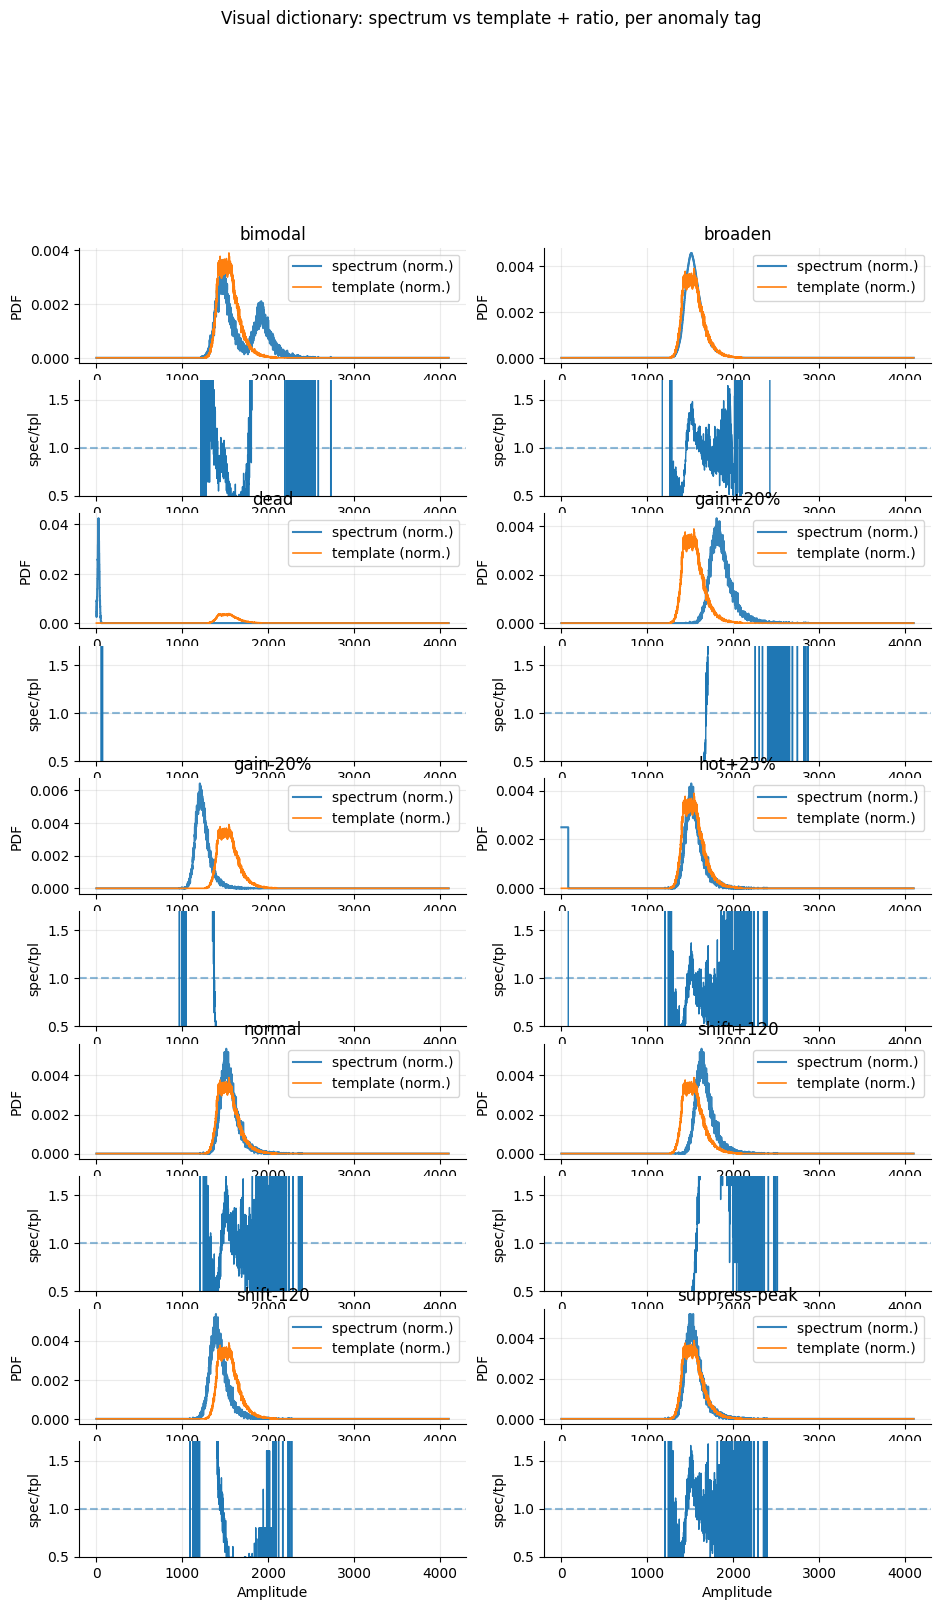

In [112]:
# Re-usable “make one representative example by tag”
def make_example_by_tag(tag):
    if tag == "normal":
        return synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7)
    if tag == "gain+20%":
        return gain_scale(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), 1.20)
    if tag == "gain-20%":
        return gain_scale(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), 0.80)
    if tag == "shift+120":
        return add_shift(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), +120)
    if tag == "shift-120":
        return add_shift(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), -120)
    if tag == "broaden":
        return broaden(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), 8)
    if tag == "hot+25%":
        return hot_threshold(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), frac=0.25, thr=80)
    if tag == "suppress-peak":
        return suppress_peak_bin(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), 0.80)
    if tag == "dead":
        return dead_like(15000, 25, 10)
    if tag == "bimodal":
        return bimodal_mix(30000, 1500, 1950, 0.35, 180, rng=7)
    # fallback: normal
    return synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7)

# Grid of panels (spectrum vs template + ratio) — one per tag
n = len(tags)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig = plt.figure(figsize=(11, 3.4*nrows))
gs = fig.add_gridspec(nrows*2, ncols, hspace=0.15)  # 2 rows per tag (pdf + ratio)

for k, tag in enumerate(tags):
    r = (k // ncols)*2
    c =  k % ncols
    h = make_example_by_tag(tag)
    spec = h / (h.sum()+1e-9)
    tpl  = template / (template.sum()+1e-9)
    ratio = np.divide(spec, tpl + 1e-12)

    ax = fig.add_subplot(gs[r, c])
    ax2= fig.add_subplot(gs[r+1, c], sharex=ax)

    ax.step(xcent, spec, where="mid", alpha=0.9, label="spectrum (norm.)")
    ax.plot(xcent, tpl, lw=1.2, label="template (norm.)")
    ax.set_title(tag); ax.set_ylabel("PDF"); ax.legend()

    ax2.plot(xcent, ratio, lw=1.0)
    ax2.axhline(1.0, ls="--", alpha=0.5)
    ax2.set_xlabel("Amplitude"); ax2.set_ylabel("spec/tpl")
    ax2.set_ylim(0.5, 1.7)

plt.suptitle("Visual dictionary: spectrum vs template + ratio, per anomaly tag", y=1.02)
plt.tight_layout()
plt.show()

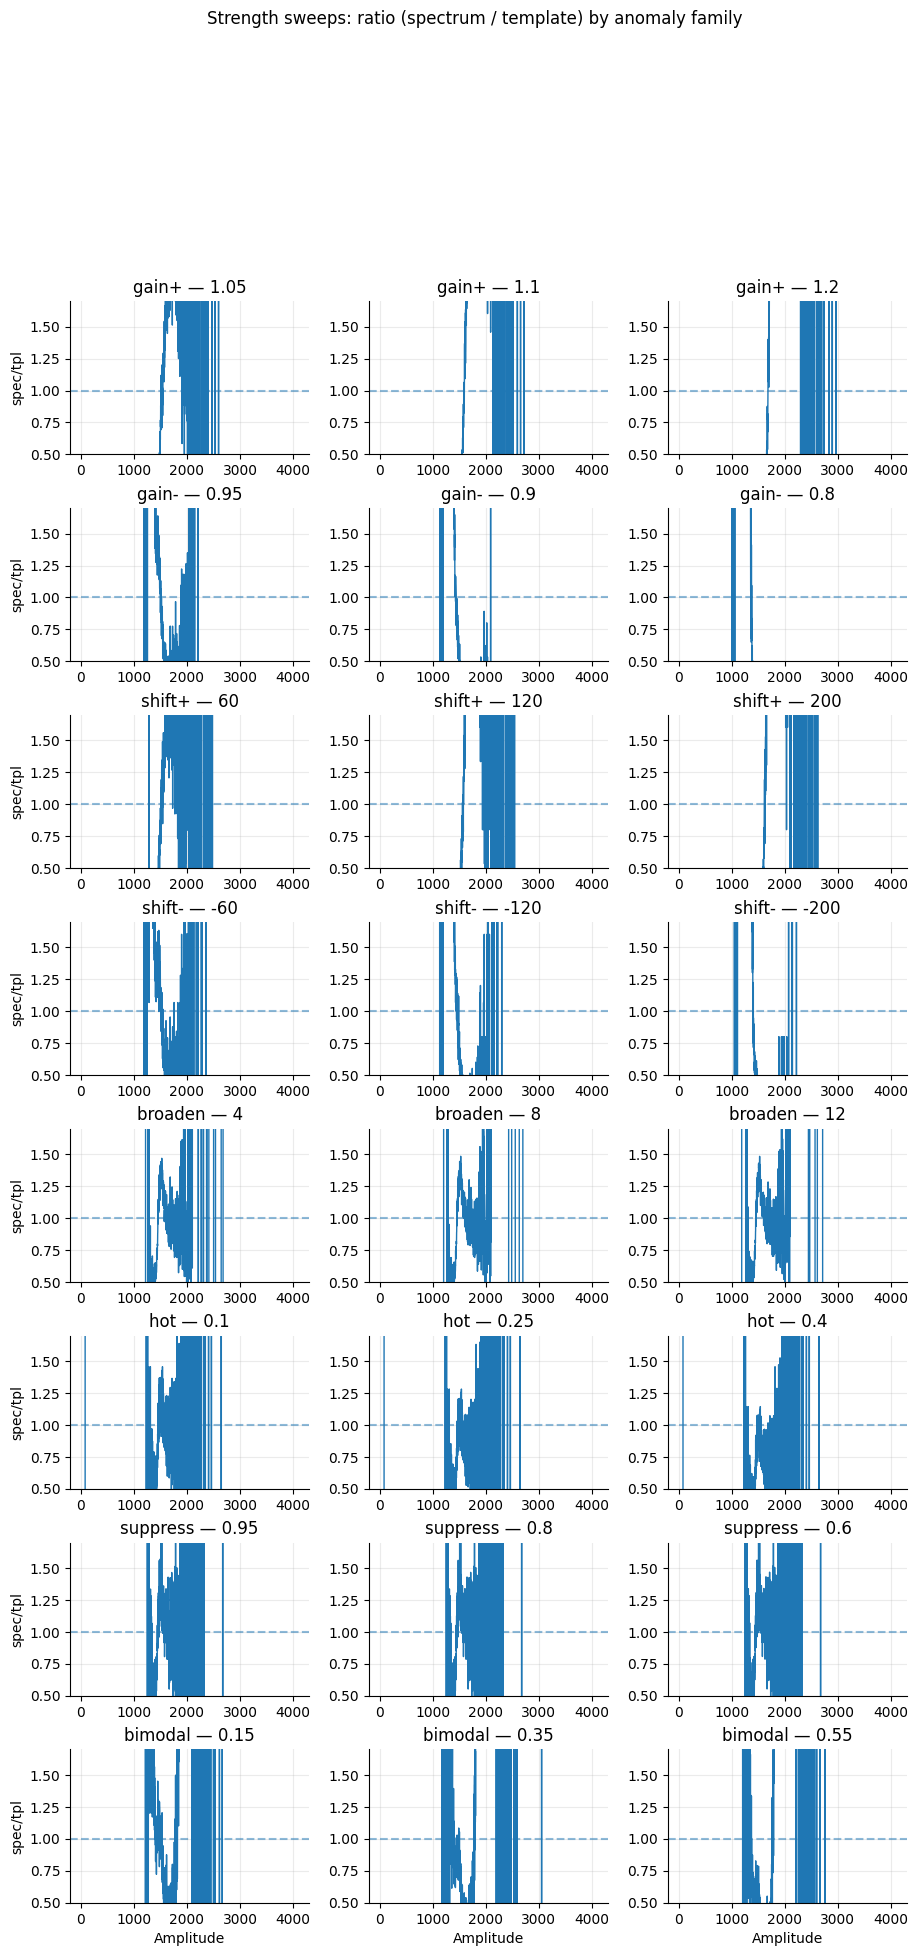

In [113]:
# Define sweep settings for each family
sweeps = {
    "gain+":   {"strengths":[1.05, 1.10, 1.20], "make": lambda s: gain_scale(synth_exgauss_hist(30000,1550,180,threshold=50,rng=123), s)},
    "gain-":   {"strengths":[0.95, 0.90, 0.80], "make": lambda s: gain_scale(synth_exgauss_hist(30000,1550,180,threshold=50,rng=124), s)},
    "shift+":  {"strengths":[+60, +120, +200],  "make": lambda d: add_shift(synth_exgauss_hist(30000,1550,180,threshold=50,rng=125), d)},
    "shift-":  {"strengths":[-60, -120, -200],  "make": lambda d: add_shift(synth_exgauss_hist(30000,1550,180,threshold=50,rng=126), d)},
    "broaden": {"strengths":[4, 8, 12],         "make": lambda s: broaden(synth_exgauss_hist(30000,1550,180,threshold=50,rng=127), s)},
    "hot":     {"strengths":[0.10, 0.25, 0.40], "make": lambda f: hot_threshold(synth_exgauss_hist(30000,1550,180,threshold=50,rng=128), frac=f, thr=80)},
    "suppress":{"strengths":[0.95, 0.80, 0.60], "make": lambda r: suppress_peak_bin(synth_exgauss_hist(30000,1550,180,threshold=50,rng=129), r)},
    "bimodal": {"strengths":[0.15, 0.35, 0.55], "make": lambda w: bimodal_mix(30000,1500,1950,w,180,rng=130)},
}

tpl = template / (template.sum()+1e-9)

nrows = len(sweeps)
ncols = max(len(v["strengths"]) for v in sweeps.values())

fig = plt.figure(figsize=(3.6*ncols, 2.6*nrows))
gs = fig.add_gridspec(nrows, ncols, hspace=0.35, wspace=0.25)

for r, (name, cfgs) in enumerate(sweeps.items()):
    for c, s in enumerate(cfgs["strengths"]):
        h = cfgs["make"](s)
        spec = h / (h.sum()+1e-9)
        ratio = np.divide(spec, tpl + 1e-12)
        ax = fig.add_subplot(gs[r, c])
        ax.plot(xcent, ratio, lw=1.0)
        ax.axhline(1.0, ls="--", alpha=0.5)
        ax.set_ylim(0.5, 1.7)
        ax.set_title(f"{name} — {s}")
        if c == 0:
            ax.set_ylabel("spec/tpl")
        if r == nrows - 1:
            ax.set_xlabel("Amplitude")

plt.suptitle("Strength sweeps: ratio (spectrum / template) by anomaly family", y=1.02)
plt.tight_layout()
plt.show()

## Training

In [62]:
def normalize(h):
    s = h.sum()
    return h / s if s > 0 else h

def hist_quantile(h, x, q):
    """q in [0,1] using cumulative counts."""
    tot = h.sum()
    if tot <= 0: return np.nan
    cum = np.cumsum(h)
    return np.interp(q * tot, cum, x)

def js_divergence(p, q, eps=1e-12):
    p = np.clip(p, eps, None); p = p / p.sum()
    q = np.clip(q, eps, None); q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (stats.entropy(p, m) + stats.entropy(q, m))

def wasserstein(p, q):
    """1D Wasserstein distance between two hist pdfs on same support."""
    p = normalize(p); q = normalize(q)
    return stats.wasserstein_distance(xcent, xcent, p, q)

def count_peaks(h, prominence=None, distance_bins=10):
    """Count significant peaks in raw histogram (very simple peak counter)."""
    y = h.astype(float)
    if prominence is None:
        prominence = max(5.0 * np.sqrt(y.max()), 0.02 * y.max())
    peaks, props = signal.find_peaks(y, prominence=prominence, distance=distance_bins)
    return len(peaks)

# Build reference template from normals (median normalized shape)
template = np.median(np.stack([normalize(h) for _,h in normals], axis=0), axis=0)

def extract_features(h, label, tag):
    # simple peak location & height
    i_max = int(np.argmax(h))
    x_max = xcent[i_max] if h.sum() > 0 else np.nan
    peak_height = h[i_max] if h.sum() > 0 else 0.0

    # weighted mean/std/skew/kurtosis using histogram as weights
    w = h.astype(float); tot = w.sum()
    mu = np.average(xcent, weights=w) if tot>0 else np.nan
    var = np.average((xcent - mu)**2, weights=w) if tot>0 else np.nan
    std = np.sqrt(var) if var==var else np.nan

    # (approx) skew/kurt via central moments
    m3 = np.average((xcent - mu)**3, weights=w) if tot>0 else np.nan
    m4 = np.average((xcent - mu)**4, weights=w) if tot>0 else np.nan
    skew = (m3 / (std**3 + 1e-12)) if std==std else np.nan
    kurt = (m4 / (std**4 + 1e-12)) if std==std else np.nan

    # quantiles and widths
    q10 = hist_quantile(h, xcent, 0.10)
    q50 = hist_quantile(h, xcent, 0.50)
    q90 = hist_quantile(h, xcent, 0.90)
    iqr = (q90 - q10) if (q90==q90 and q10==q10) else np.nan

    # shape descriptors
    n_pk = count_peaks(h)
    jsd  = js_divergence(h, template) if template.sum()>0 else np.nan
    wdist = wasserstein(h, template)   if template.sum()>0 else np.nan

    # normalized peak contrast
    peak_contrast = (peak_height / (tot + 1e-9)) if tot>0 else 0.0

    return {
        "label": label, "tag": tag,
        "x_max": x_max, "peak_height": peak_height,
        "mean": mu, "std": std, "skew": skew, "kurt": kurt,
        "q10": q10, "q50": q50, "q90": q90, "iqr": iqr,
        "n_peaks": n_pk,
        "jsd_to_template": jsd,
        "wdist_to_template": wdist,
        "peak_contrast": peak_contrast
    }

# Assemble dataset (features + raw references for plotting)
rows, raw = [], []

for i,(nm,h) in enumerate(normals):
    rows.append(extract_features(h, label=0, tag="normal"))
    raw.append(("N%02d" % i, "normal", h))

for i,(tag,h) in enumerate(anoms):
    rows.append(extract_features(h, label=1, tag=tag))
    raw.append(("A%02d" % i, tag, h))

df = pd.DataFrame(rows)
print(df.shape)
df.head()

(90, 16)


,label,tag,x_max,peak_height,mean,std,skew,kurt,q10,q50,q90,iqr,n_peaks,jsd_to_template,wdist_to_template,peak_contrast
0,0,normal,1569.5,175.0,1577.688033,99.701234,1.178532,6.075650,1468.691176,1562.531847,1703.012195,234.321019,1,0.047297,36.677589,0.005833
1,0,normal,1644.5,177.0,1675.374300,102.816975,1.137648,5.683174,1562.500000,1659.374214,1805.094595,242.594595,1,0.209010,134.354268,0.005900
2,0,normal,1340.5,178.0,1378.541500,100.235228,1.183595,5.992936,1268.696970,1363.485612,1504.880952,236.183983,1,0.260201,162.489811,0.005933
3,0,normal,1576.5,138.0,1590.914933,123.375050,1.150386,6.013565,1454.254098,1573.603774,1745.958333,291.704235,1,0.033075,49.900005,0.004600
4,0,normal,1477.5,155.0,1486.505133,116.043116,1.105944,5.472576,1358.921875,1468.717742,1635.568182,276.646307,1,0.041121,54.805811,0.005167


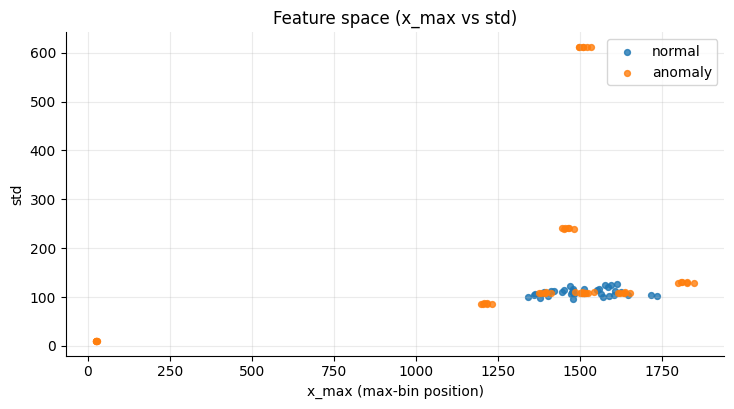

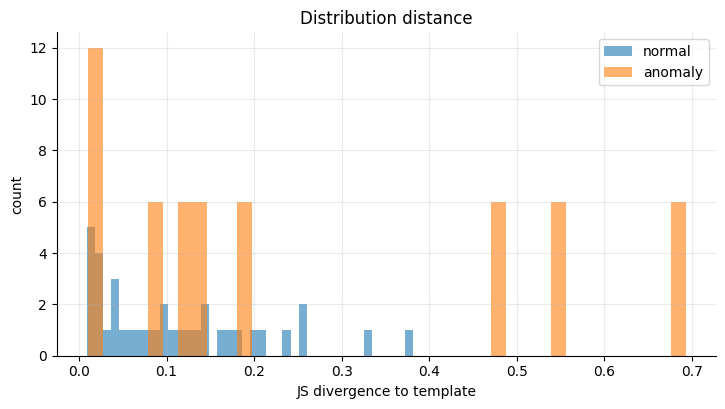

In [63]:
# Old-peak location vs. std
plt.figure()
plt.scatter(df[df.label==0]["x_max"], df[df.label==0]["std"], s=18, label="normal", alpha=0.8)
plt.scatter(df[df.label==1]["x_max"], df[df.label==1]["std"], s=18, label="anomaly", alpha=0.8)
plt.xlabel("x_max (max-bin position)"); plt.ylabel("std")
plt.title("Feature space (x_max vs std)"); plt.legend(); plt.show()

# Distances to template
plt.figure()
plt.hist(df[df.label==0]["jsd_to_template"], bins=40, alpha=0.6, label="normal")
plt.hist(df[df.label==1]["jsd_to_template"], bins=40, alpha=0.6, label="anomaly")
plt.xlabel("JS divergence to template"); plt.ylabel("count")
plt.title("Distribution distance"); plt.legend(); plt.show()

In [64]:
# Train only on NORMALS (unsupervised novelty detection setting)
df_norm = df[df.label==0].copy()
df_all  = df.copy()

feature_cols = [
    "x_max","peak_height","mean","std","skew","kurt",
    "q10","q50","q90","iqr",
    "n_peaks","peak_contrast",
    "jsd_to_template","wdist_to_template"
]

X_train = df_norm[feature_cols].to_numpy()
X_all   = df_all[feature_cols].to_numpy()
y_all   = df_all["label"].to_numpy().astype(int)

# Standardize by normal-only stats (robust scaling optional)
mu = np.nanmean(X_train, axis=0)
sd = np.nanstd(X_train, axis=0, ddof=1)
sd[sd==0] = 1.0

def zscore(X): return (X - mu) / sd

Z_train = zscore(X_train)
Z_all   = zscore(X_all)

# Replace NaNs that may arise from degenerate histograms
Z_train = np.nan_to_num(Z_train, nan=0.0, posinf=0.0, neginf=0.0)
Z_all   = np.nan_to_num(Z_all,   nan=0.0, posinf=0.0, neginf=0.0)

In [65]:
results = []

# --- Z-score max baseline ---
score_z = np.abs(Z_all).max(axis=1)
auc_z = roc_auc_score(y_all, score_z)
ap_z  = average_precision_score(y_all, score_z)
results.append(("Zscore(max)", auc_z, ap_z, score_z))

# --- PCA + Mahalanobis ---
pca = PCA(n_components=min(6, Z_train.shape[1]))
pca.fit(Z_train)
Zp_all = pca.transform(Z_all)
muZ = Zp_all[df_all.label==0].mean(axis=0)
covZ = np.cov(Zp_all[df_all.label==0].T) + 1e-6*np.eye(Zp_all.shape[1])
invC = np.linalg.pinv(covZ)
md2  = np.einsum("ij,jk,ik->i", (Zp_all-muZ), invC, (Zp_all-muZ))
auc_md = roc_auc_score(y_all, md2)
ap_md  = average_precision_score(y_all, md2)
results.append(("PCA+Mahalanobis", auc_md, ap_md, md2))

# --- Isolation Forest ---
iso = IsolationForest(n_estimators=300, contamination=0.20, random_state=0)
iso.fit(Z_train)
s_if = -iso.score_samples(Z_all)  # higher = more anomalous
auc_if = roc_auc_score(y_all, s_if)
ap_if  = average_precision_score(y_all, s_if)
results.append(("IsolationForest", auc_if, ap_if, s_if))

# --- One-Class SVM ---
oc = OneClassSVM(kernel="rbf", nu=0.20, gamma="scale")
oc.fit(Z_train)
s_oc = -oc.decision_function(Z_all).ravel()
auc_oc = roc_auc_score(y_all, s_oc)
ap_oc  = average_precision_score(y_all, s_oc)
results.append(("OneClassSVM", auc_oc, ap_oc, s_oc))

# --- LOF novelty detection (train on normals, then decision_function on all) ---
lof = LocalOutlierFactor(n_neighbors=20, novelty=True)
lof.fit(Z_train)
s_lof = -lof.decision_function(Z_all)
auc_lof = roc_auc_score(y_all, s_lof)
ap_lof  = average_precision_score(y_all, s_lof)
results.append(("LOF(novelty)", auc_lof, ap_lof, s_lof))

pd.DataFrame([(n, f"{a:.3f}", f"{p:.3f}") for (n,a,p,_) in results],
             columns=["Method","ROC-AUC","PR-AUC"])

,Method,ROC-AUC,PR-AUC
0,Zscore(max),0.782,0.876
1,PCA+Mahalanobis,0.776,0.886
2,IsolationForest,0.747,0.857
3,OneClassSVM,0.801,0.905
4,LOF(novelty),0.764,0.867


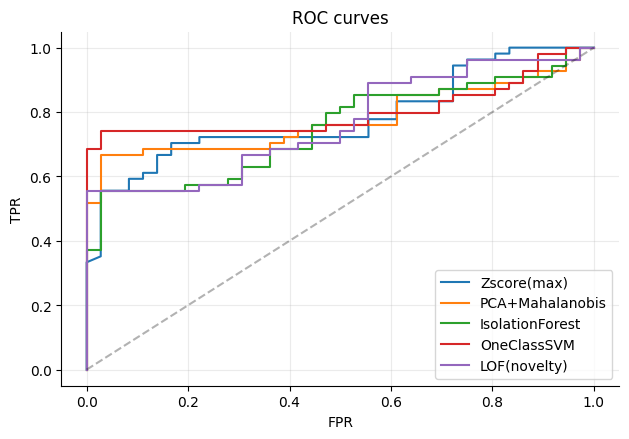

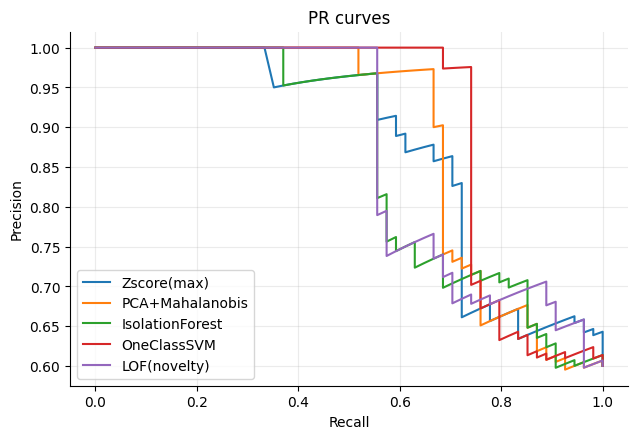

,Method,ROC-AUC,PR-AUC,F1*,thr,TP,FP,TN,FN
0,Zscore(max),0.782,0.876,0.783,1.056,54,31,5,0
1,PCA+Mahalanobis,0.776,0.886,0.791,11.401,36,2,34,18
2,IsolationForest,0.747,0.857,0.773,0.456,46,20,16,8
3,OneClassSVM,0.801,0.905,0.842,0.000,40,2,34,14
4,LOF(novelty),0.764,0.867,0.787,-0.511,48,21,15,6


In [66]:
def best_f1(y_true, scores):
    P, R, T = precision_recall_curve(y_true, scores)
    F = 2*P*R/(P+R+1e-12)
    i = int(np.nanargmax(F))
    thr = T[i-1] if i>0 else T[0]
    return float(F[i]), float(thr), float(P[i]), float(R[i])

# ROC
plt.figure(figsize=(7.2, 4.6))
for (name,_,_,s) in results:
    fpr,tpr,_ = roc_curve(y_all, s)
    plt.plot(fpr,tpr,label=name)
plt.plot([0,1],[0,1],'k--',alpha=0.3)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC curves"); plt.legend(); plt.show()

# PR
plt.figure(figsize=(7.2, 4.6))
for (name,_,_,s) in results:
    P,R,_ = precision_recall_curve(y_all, s)
    plt.plot(R,P,label=name)
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("PR curves"); plt.legend(); plt.show()

# Confusion tables at best-F1
rows = []
for (name, auc, ap, s) in results:
    f1, thr, P, R = best_f1(y_all, s)
    yhat = (s >= thr).astype(int)
    tp = int(((y_all==1)&(yhat==1)).sum()); fp = int(((y_all==0)&(yhat==1)).sum())
    tn = int(((y_all==0)&(yhat==0)).sum()); fn = int(((y_all==1)&(yhat==0)).sum())
    rows.append([name, f"{auc:.3f}", f"{ap:.3f}", f"{f1:.3f}", f"{thr:.3f}", tp, fp, tn, fn])

pd.DataFrame(rows, columns=["Method","ROC-AUC","PR-AUC","F1*","thr","TP","FP","TN","FN"])

## Testing

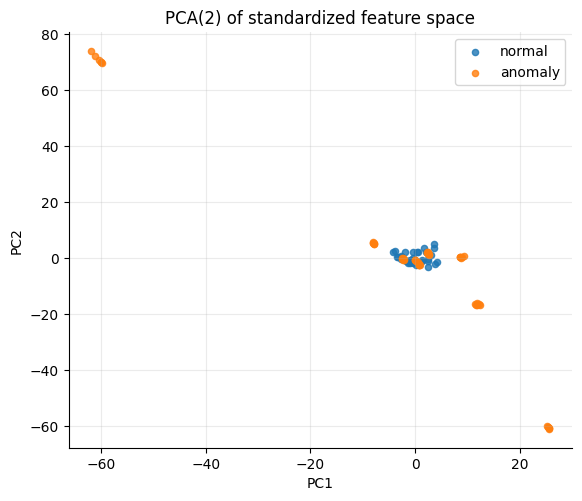

Top anomalies by: OneClassSVM


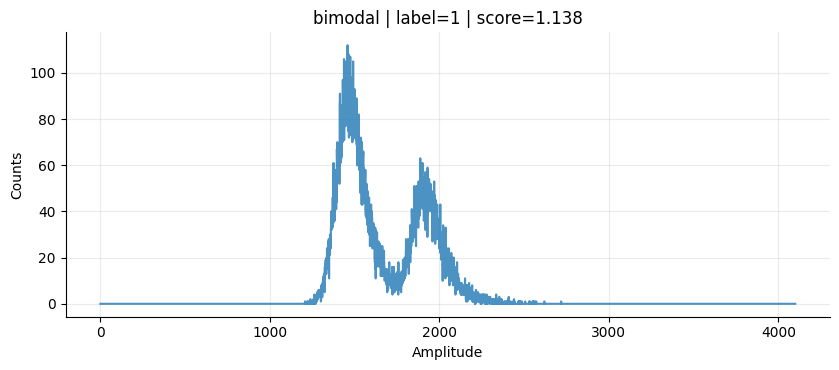

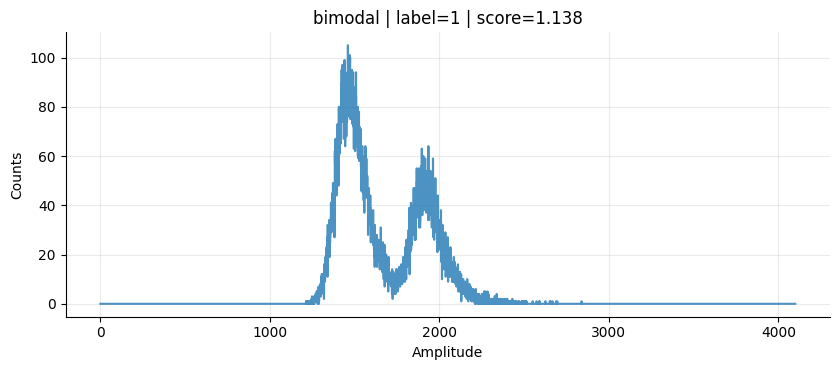

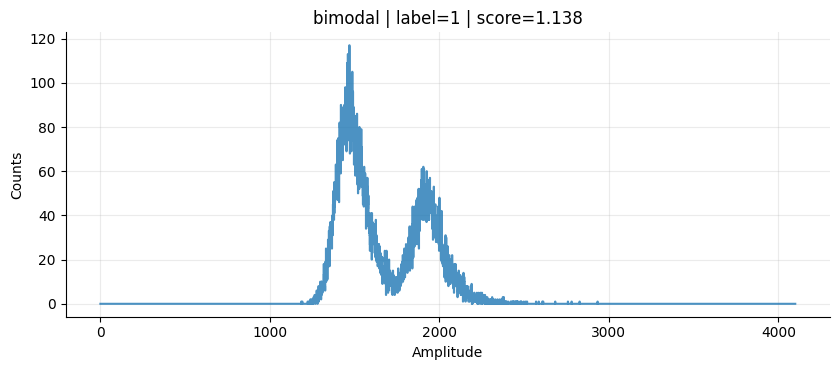

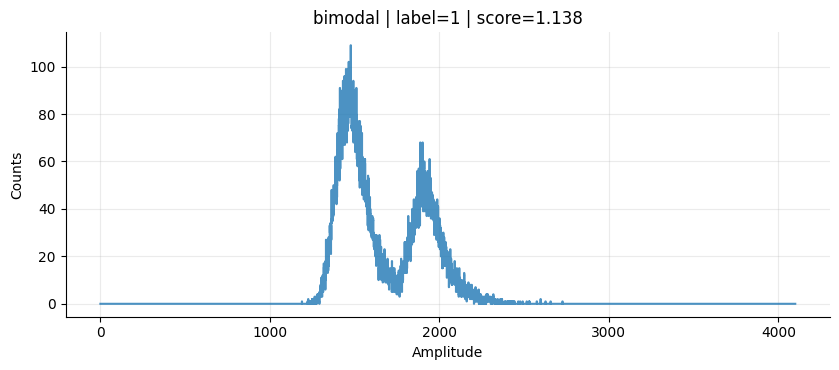

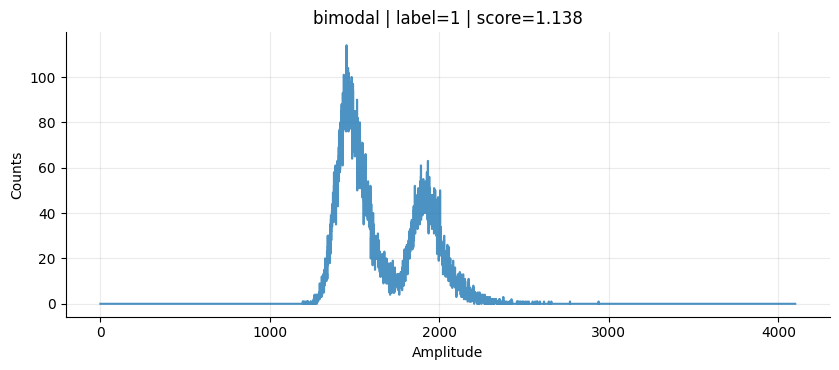

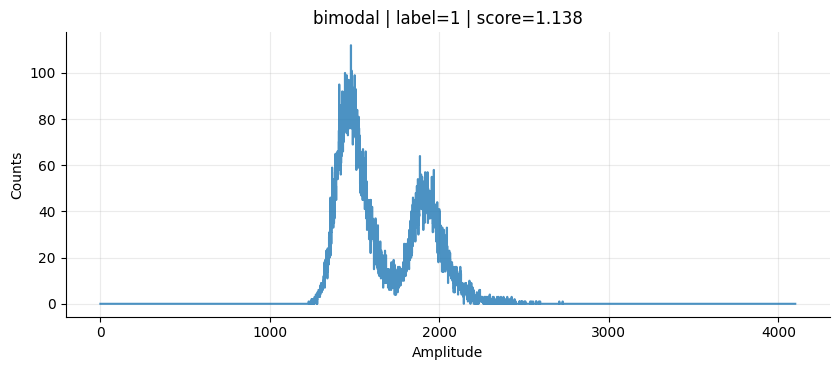

In [67]:
# 2D PCA purely for visualization (fit on normals)
p2 = PCA(n_components=2).fit(Z_train)
Z2 = p2.transform(Z_all)

plt.figure(figsize=(6.5, 5.4))
plt.scatter(Z2[df_all.label==0,0], Z2[df_all.label==0,1], s=20, alpha=0.8, label="normal")
plt.scatter(Z2[df_all.label==1,0], Z2[df_all.label==1,1], s=20, alpha=0.8, label="anomaly")
plt.title("PCA(2) of standardized feature space")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.show()

# Show spectra of top anomalies for the best (highest ROC-AUC) method
best_name, _, _, best_scores = max(results, key=lambda r: r[1])
print("Top anomalies by:", best_name)
idx = np.argsort(best_scores)[::-1][:6]

# Map back to raw spectra we stored
def show_raw(idx_list):
    for i in idx_list:
        who_tag = df_all.iloc[i]["tag"]
        lbl = df_all.iloc[i]["label"]
        # reconstruct: find a matching raw sample by tag (approximate display)
        # here we just generate a representative spectrum per tag:
        if who_tag == "normal":
            h = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
        elif who_tag == "gain+20%":
            base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
            h = gain_scale(base, 1.20)
        elif who_tag == "gain-20%":
            base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
            h = gain_scale(base, 0.80)
        elif who_tag == "shift+120":
            base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
            h = add_shift(base, +120)
        elif who_tag == "shift-120":
            base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
            h = add_shift(base, -120)
        elif who_tag == "broaden":
            base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
            h = broaden(base, 8)
        elif who_tag == "hot+25%":
            base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
            h = hot_threshold(base, frac=0.25, thr=80)
        elif who_tag == "suppress-peak":
            base = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)
            h = suppress_peak_bin(base, 0.80)
        elif who_tag == "dead":
            h = dead_like(cfg.events_per_ch//2, mu=25, sigma=10)
        elif who_tag == "bimodal":
            h = bimodal_mix(cfg.events_per_ch, mpv1=1500, mpv2=1950, w2=0.35, xi=cfg.xi_base, rng=rng)
        else:
            h = synth_exgauss_hist(cfg.events_per_ch, cfg.mpv_base, cfg.xi_base, threshold=cfg.threshold, rng=rng)

        plt.figure(figsize=(8.5, 3.8))
        plt.step(xcent, h, where="mid", alpha=0.8)
        plt.title(f"{who_tag} | label={lbl} | score={best_scores[i]:.3f}")
        plt.xlabel("Amplitude"); plt.ylabel("Counts"); plt.tight_layout(); plt.show()

show_raw(idx)

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# --- If not already in memory from the POC cells, ensure these exist ---
assert 'df' in globals() and 'df_all' in globals() if 'df_all' in globals() else True
df_all = df  # in this POC df == df_all
assert 'feature_cols' in globals()
assert 'Z_train' in globals() and 'Z_all' in globals()
assert 'pca' in globals() and 'Zp_all' in globals() and 'muZ' in globals() and 'invC' in globals()
assert 'results' in globals()  # list of (name, auc, ap, scores)

# ---------- draw covariance ellipse (PCA space) ----------
def draw_cov_ellipse(ax, mean, cov, nsig=2.0, **kwargs):
    """Draw an ellipse for a 2x2 covariance in 2D."""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:,order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2*nsig*np.sqrt(vals)
    ellip = Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)
    ax.add_artist(ellip)
    return ellip

def cov_2x2_from_full(cov_full):
    """Return 2x2 covariance of PC1,PC2 from full PCA covariance."""
    return cov_full[:2,:2]

# ---------- simple rule-based explanation from feature z-scores ----------
def explain_feature_contributions(z_row, feat_names, top_k=4):
    absz = np.abs(z_row)
    idx = np.argsort(absz)[::-1][:top_k]
    top = [(feat_names[i], z_row[i]) for i in idx]
    tags = []
    for name, z in top:
        s = abs(z)
        if name in {"x_max","mean","q50"} and s>2: tags.append("gain/shift")
        if name in {"std","iqr"} and s>2: tags.append("broadening/noise")
        if name in {"peak_contrast"} and s>2: tags.append("peak suppression / hot / dead")
        if name in {"n_peaks"} and s>2: tags.append("multi-modal / hot")
        if name in {"jsd_to_template","wdist_to_template"} and s>2: tags.append("shape change vs template")
    tags = list(dict.fromkeys(tags))  # unique preserve order
    return top, tags

# ---------- decision contour helpers in PCA(2) space ----------
def grid_decision_contour(model, X2, padding=0.5, n=150, method="iforest"):
    """Grid decision values for a 2D array X2 (PC1,PC2)."""
    x_min, x_max = X2[:,0].min()-padding, X2[:,0].max()+padding
    y_min, y_max = X2[:,1].min()-padding, X2[:,1].max()+padding
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n),
                         np.linspace(y_min, y_max, n))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # We trained on Z (full feature space). Here we need to invert from PCA(2) back to Z-space:
    # Use only first 2 PCs to approximate: Z ≈ grid @ pca.components_[:2] + meanZ_in_Zspace
    # We'll build a minimal surrogate that maps PC2 -> Z for scoring.
    #   Z_all = pca.transform(Z) -> Z ≈ (Zp @ pca.components_) + pca.mean_
    # So inverse approx: Z ≈ grid_full @ components[:2] + mean_Z
    components = pca.components_[:2]  # shape (2,D)
    Z_grid = grid @ components   # (n^2, D)
    Z_grid += pca.mean_

    if method == "iforest":
        vals = -iso.score_samples(Z_grid)
    elif method == "ocsvm":
        vals = -oc.decision_function(Z_grid).ravel()
    else:
        vals = np.zeros(len(Z_grid))
    return xx, yy, vals.reshape(xx.shape)

# ---------- spectrum vs template (with ratio sub-plot) ----------
def plot_spectrum_vs_template(h, title, template=None, x=xcent, ratio_ylim=(0.5,1.5)):
    if template is None:
        template = np.ones_like(h)
    tpl = template / (template.sum()+1e-9)
    spec = h / (h.sum()+1e-9)
    ratio = np.divide(spec, tpl + 1e-12)

    fig = plt.figure(figsize=(9.5, 5.2))
    gs = fig.add_gridspec(2, 1, height_ratios=[3,1], hspace=0.05)
    ax  = fig.add_subplot(gs[0,0])
    a2  = fig.add_subplot(gs[1,0], sharex=ax)

    ax.step(x, spec, where="mid", label="spectrum (norm.)", alpha=0.9)
    ax.plot(x, tpl, label="template (norm.)", lw=1.4)
    ax.set_ylabel("PDF"); ax.set_title(title); ax.legend()

    a2.plot(x, ratio, lw=1.0)
    a2.axhline(1.0, color="k", ls="--", alpha=0.5)
    a2.set_xlabel("Amplitude"); a2.set_ylabel("spec/tpl")
    if ratio_ylim: a2.set_ylim(*ratio_ylim)
    plt.setp(ax.get_xticklabels(), visible=False)
    plt.show()

In [79]:
# --- PATCH: robust contours + safe levels for IsolationForest / OCSVM in PCA(2) ---

import numpy as np
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _safe_contour_levels(Z, desired=(0.70, 0.85, 0.95)):
    """Return strictly increasing contour levels or None if not possible."""
    vals = np.asarray(Z).ravel()
    vals = vals[np.isfinite(vals)]
    if vals.size < 10:
        return None
    q = np.quantile(vals, desired)
    q = np.unique(np.sort(q))
    # enforce strictly increasing with a small epsilon if needed
    if q.size >= 2 and np.all(np.diff(q) > 1e-12):
        return q
    vmin, vmax = float(vals.min()), float(vals.max())
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
        return None
    # fallback: spaced levels strictly between min and max
    a = vmin + 0.15 * (vmax - vmin)
    b = vmin + 0.50 * (vmax - vmin)
    c = vmin + 0.85 * (vmax - vmin)
    levels = np.array([a, b, c], dtype=float)
    if np.all(np.diff(levels) > 0):
        return levels
    return None

def draw_cov_ellipse(ax, mean, cov, nsig=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2*nsig*np.sqrt(np.maximum(vals, 1e-12))
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta, **kwargs)
    ax.add_artist(ell)
    return ell

def grid_decision_contour(model, X2, padding=0.5, n=150, method="iforest"):
    """
    Build a PC1-PC2 grid, map back into Z-space via PCA inverse approx, and score.
    Requires global `pca`, `iso`, `oc` as trained on Z-space.
    """
    x_min, x_max = X2[:,0].min()-padding, X2[:,0].max()+padding
    y_min, y_max = X2[:,1].min()-padding, X2[:,1].max()+padding
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n),
                         np.linspace(y_min, y_max, n))
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Inverse PCA approx to Z-space (use first 2 PCs)
    comps = pca.components_[:2]              # shape (2, D)
    Z_grid = grid @ comps                    # (n^2, D) (PC2 -> Z)
    Z_grid = Z_grid + pca.mean_              # center back

    if method == "iforest":
        vals = -iso.score_samples(Z_grid)
    elif method == "ocsvm":
        vals = -oc.decision_function(Z_grid).ravel()
    else:
        vals = np.zeros(len(Z_grid))
    return xx, yy, vals.reshape(xx.shape)

def _add_contour_legend_proxy(ax, label, color=None, lw=1.0, ls='-'):
    """
    Add a dummy handle so the legend shows a label for the contour set,
    even if QuadContourSet lacks 'collections'.
    """
    ax.plot([], [], ls=ls, lw=lw, color=color if color else '0.3', label=label)

# Re-define explain_instance with safe labeling for contours
def explain_instance(i, method_name="IsolationForest"):
    row = df_all.iloc[i]
    tag  = row["tag"]; label = int(row["label"])

    # Representative spectrum for this tag
    def synth_by_tag(tag):
        if tag == "normal":
            return synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7)
        if tag == "gain+20%":
            return gain_scale(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), 1.20)
        if tag == "gain-20%":
            return gain_scale(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), 0.80)
        if tag == "shift+120":
            return add_shift(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), +120)
        if tag == "shift-120":
            return add_shift(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), -120)
        if tag == "broaden":
            return broaden(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), 8)
        if tag == "hot+25%":
            return hot_threshold(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), frac=0.25, thr=80)
        if tag == "suppress-peak":
            return suppress_peak_bin(synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7), 0.80)
        if tag == "dead":
            return dead_like(15000, 25, 10)
        if tag == "bimodal":
            return bimodal_mix(30000, 1500, 1950, 0.35, 180, rng=7)
        return synth_exgauss_hist(30000, 1550, 180, threshold=50, rng=7)

    h = synth_by_tag(tag)
    plot_spectrum_vs_template(h, f"Sample {i} | tag={tag} | label={label}", template=template)

    # Feature z-scores panel
    X_i = df_all.loc[[i], feature_cols].to_numpy()
    Z_i = np.nan_to_num((X_i - mu)/sd, nan=0.0, posinf=0.0, neginf=0.0)[0]
    top, tags = explain_feature_contributions(Z_i, feature_cols, top_k=6)
    plt.figure(figsize=(9.5, 4.2))
    order = np.argsort(np.abs(Z_i))[::-1][:12]
    plt.bar(np.array(feature_cols)[order], Z_i[order])
    plt.axhline(+2, color="r", ls="--", alpha=0.5); plt.axhline(-2, color="r", ls="--", alpha=0.5)
    plt.title(f"Feature z-scores (|z|>2). Likely causes: {', '.join(tags) if tags else '—'}")
    plt.ylabel("z"); plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

    # PCA(2) + ellipse + decision contours
    Z2 = pca.transform(Z_all)[:, :2]
    Zi = pca.transform(((X_i - mu) / sd))[:, :2][0]
    cov_full = np.cov(Zp_all[df_all.label==0].T) + 1e-6*np.eye(Zp_all.shape[1])
    cov2 = cov_full[:2,:2]

    fig, ax = plt.subplots(1, 1, figsize=(7.6, 5.6))
    ax.scatter(Z2[df_all.label==0,0], Z2[df_all.label==0,1], s=12, alpha=0.6, label="normal")
    ax.scatter(Z2[df_all.label==1,0], Z2[df_all.label==1,1], s=12, alpha=0.6, label="anomaly")
    draw_cov_ellipse(ax, muZ[:2], cov2, nsig=2.45, edgecolor="g", facecolor="none", lw=1.2, label="~95% ellipse")
    ax.scatter([Zi[0]],[Zi[1]], s=120, c="k", marker="x", label=f"this sample")

    lname = method_name.lower()
    if lname.startswith("iso"):
        xx, yy, zz = grid_decision_contour(iso, Z2, method="iforest")
        levels = _safe_contour_levels(zz)
        if levels is not None:
            cs = ax.contour(xx, yy, zz, levels=levels, alpha=0.75, linewidths=1.0, colors='C1')
            _add_contour_legend_proxy(ax, "IF contours", color='C1')
    elif lname.startswith("one") or "svm" in lname:
        xx, yy, zz = grid_decision_contour(oc, Z2, method="ocsvm")
        levels = _safe_contour_levels(zz)
        if levels is not None:
            cs = ax.contour(xx, yy, zz, levels=levels, alpha=0.75, linewidths=1.0, colors='C3')
            _add_contour_legend_proxy(ax, "OCSVM contours", color='C3')

    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_title(f"PCA(2) — {method_name} view (sample {i})")
    ax.legend(loc="best"); plt.show()

    print("— EXPLANATION —")
    print(f"Sample {i} | tag={tag} | label={label} (1=anomaly)")
    print("Top contributing features (name : z):")
    for n, z in top:
        print(f"  • {n:>18s} : {z:+.2f}")
    if tags:
        print("Likely anomaly families:", ", ".join(tags))
    else:
        print("No clear dominant family inferred.")

Explaining top 5 anomalies by: OneClassSVM (ROC-AUC=0.801, PR-AUC=0.905)


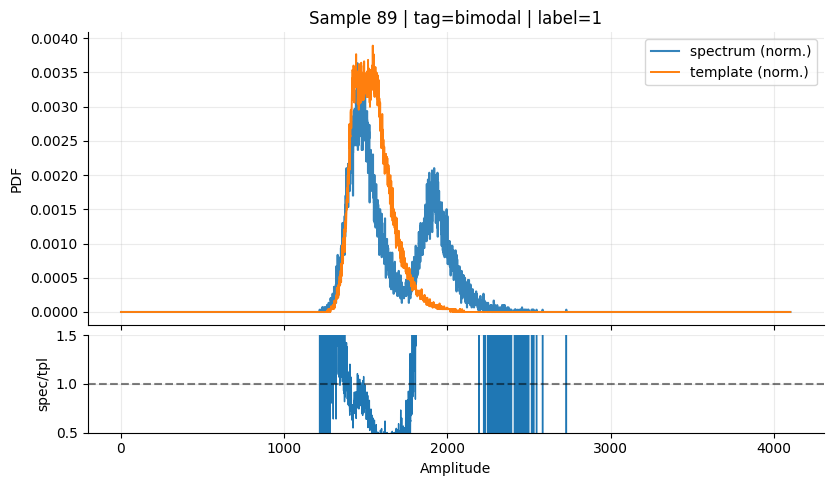

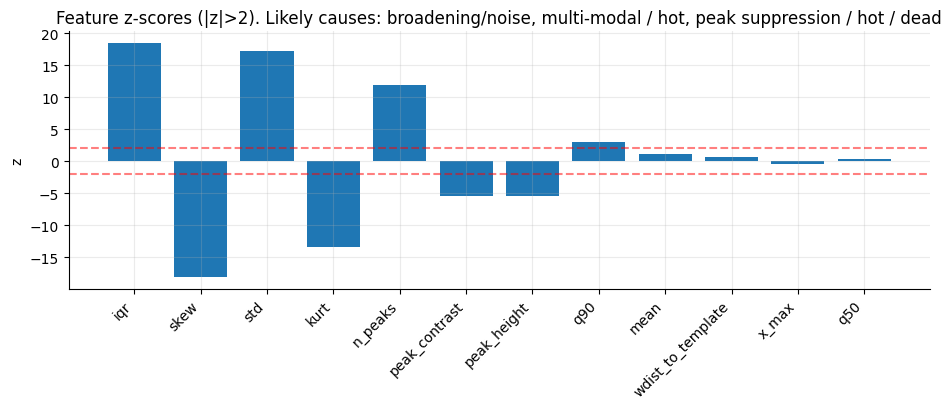

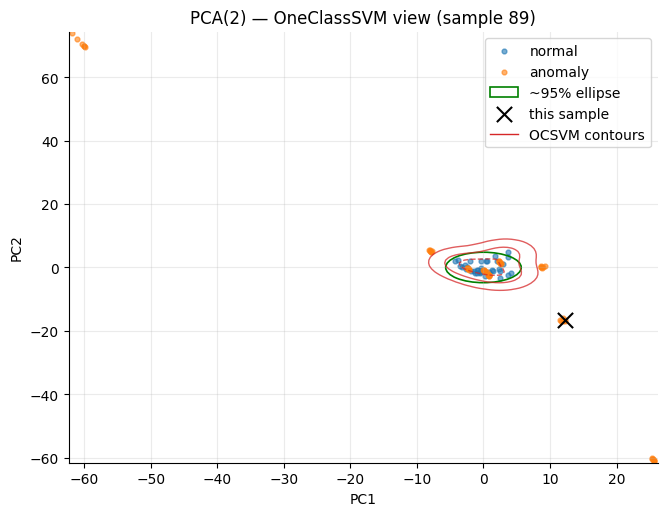

— EXPLANATION —
Sample 89 | tag=bimodal | label=1 (1=anomaly)
Top contributing features (name : z):
  •                iqr : +18.45
  •               skew : -18.16
  •                std : +17.22
  •               kurt : -13.44
  •            n_peaks : +11.83
  •      peak_contrast : -5.50
Likely anomaly families: broadening/noise, multi-modal / hot, peak suppression / hot / dead


In [115]:
# Pick the method by name (exactly as printed in the summary table)
EXPLAIN_METHOD = "OneClassSVM"   # or "OneClassSVM" or "PCA+Mahalanobis" or "Zscore(max)" (contours only for IF/OCSVM)

# choose top anomalies by that method's score
ref = next((r for r in results if r[0] == EXPLAIN_METHOD), None)
if ref is None:
    print("Method not found in results; showing PCA+Mahalanobis fall-back.")
    ref = next(r for r in results if r[0] == "PCA+Mahalanobis")

name, auc, ap, scores = ref
print(f"Explaining top 5 anomalies by: {name} (ROC-AUC={auc:.3f}, PR-AUC={ap:.3f})")

idx_sorted = np.argsort(scores)[::-1]
to_show = idx_sorted[:1]
for i in to_show:
    explain_instance(int(i), method_name=name)